**MATRIZ DE CORRELACIÓN**

In [279]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [280]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [281]:
#df = pd.read_csv('/content/drive/MyDrive/Capstone/Base filtrada.csv', encoding='latin1')
df = pd.read_csv('Base filtrada.csv', encoding='latin1')

display(df.head())
print(df.info())
print(f"Duplicados: {df.duplicated().sum()}")

,FECHA,AÑO,MES,CANAL,REGION,CIUDAD,CL_CODIGO,LOTE,VENCIMIENTO,NUM_COMPRO,PEDIDO,MOTIVO,ID_PRODUCTO,UNIDADES,Valor_Neto,Valor_Bruto,Dcto,Porcentaje_Descuento,Línea,Nombre anonimizado,Caracterísitca,Antigüedad,Categoría,UNIDAD_VENTA,PRECIO_NETO,PRECIO_LISTA,Caducidad,Año_antiguedad,Costo_Unitario,dum_Bonificacion,dum_DSCTO_PROMO,dum_Dscto_Tabla
0,16/3/2023,2023,MARZO,CADENA DE FARMACIA,SIERRA,QUITO,13704,M22AJPH,3/4/2023,7040501169,NaN,FC,10230432,25200.0,54301.67598,90502.79330,36201.117320,0.4000,RESPIRATORIA,RESPIRATORIO 1,ANTIALERGICO,2010.0,Cadena Grande,ST,2.154828,3.591381,18.0,13.0,0.268500,0.0,0.0,1.0
1,28/5/2022,2022,MAYO,CADENA DE FARMACIA,COSTA,GUAYAQUIL,11,K21ABPM,31/10/2024,7039733443,0 - ***,FC - VENTA,10115101,19209.0,10452.65363,11497.80527,1045.151636,0.0909,CONSUMO,CONSUMO 3,RELAJANTE MUSCULAR,2020.0,Cadena Grande,NaN,0.544154,0.598563,887.0,2.0,0.332582,0.0,0.0,1.0
2,29/3/2023,2023,MARZO,CADENA DE FARMACIA,SIERRA,QUITO,13704,M22AJQM,3/4/2023,7040533180,NaN,FC,10115101,19200.0,10102.98484,11492.41820,1389.433360,0.1209,CONSUMO,CONSUMO 3,RELAJANTE MUSCULAR,2020.0,Cadena Grande,ST,0.526197,0.598563,5.0,3.0,0.346221,0.0,0.0,1.0
3,29/11/2022,2022,NOVIEMBRE,CADENA DE FARMACIA,COSTA,GUAYAQUIL,11,K22AHXQ,31/10/2025,7040248183,null - ***,FC - VENTA,10230432,19174.0,61210.66241,68861.13328,7650.470870,0.1111,RESPIRATORIA,RESPIRATORIO 1,ANTIALERGICO,2010.0,Cadena Grande,NaN,3.192378,3.591381,1067.0,12.0,0.268500,0.0,0.0,1.0
4,15/1/2025,2025,ENERO,CADENA DE FARMACIA,SIERRA,QUITO,14141,M23APPP,31/12/2026,7041969081,NaN,FC,10230432,18839.0,63148.27614,71040.92179,7892.645650,0.1111,RESPIRATORIA,RESPIRATORIO 1,ANTIALERGICO,2010.0,Cadena Mediana,NaN,3.351997,3.770950,715.0,15.0,0.302478,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80350 entries, 0 to 80349
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   FECHA                 80350 non-null  object 
 1   AÑO                   80350 non-null  int64  
 2   MES                   80350 non-null  object 
 3   CANAL                 80350 non-null  object 
 4   REGION                80350 non-null  object 
 5   CIUDAD                80350 non-null  object 
 6   CL_CODIGO             80350 non-null  int64  
 7   LOTE                  80350 non-null  object 
 8   VENCIMIENTO           80350 non-null  object 
 9   NUM_COMPRO            80350 non-null  int64  
 10  PEDIDO                43513 non-null  object 
 11  MOTIVO                80350 non-null  object 
 12  ID_PRODUCTO           80350 non-null  int64  
 13  UNIDADES              80349 non-null  float64
 14  Valor_Neto            80349 non-null  float64
 15  Valor_Bruto        

In [282]:
import unicodedata
import re

def clean_col_name(col_name):
    # Convertir a minúsculas
    cleaned_name = col_name.lower()
    # Reemplazar espacios con guiones bajos
    cleaned_name = cleaned_name.replace(' ', '_')
    # Normalizar caracteres Unicode (por ejemplo, caracteres acentuados) y convertirlos a ASCII
    cleaned_name = unicodedata.normalize('NFKD', cleaned_name).encode('ascii', 'ignore').decode('utf-8')
    # Eliminar cualquier carácter que no sea una letra, número o guión bajo
    cleaned_name = re.sub(r'[^a-z0-9_]', '', cleaned_name)
    return cleaned_name

# Aplicar la función de limpieza a todos los nombres de columna
new_columns = [clean_col_name(col) for col in df.columns]
df.columns = new_columns

print("Nuevos nombres de columnas:")
print(df.columns)
display(df.head())

Nuevos nombres de columnas:
Index(['fecha', 'ano', 'mes', 'canal', 'region', 'ciudad', 'cl_codigo', 'lote', 'vencimiento', 'num_compro', 'pedido', 'motivo', 'id_producto', 'unidades', 'valor_neto', 'valor_bruto', 'dcto',
       'porcentaje_descuento', 'linea', 'nombre_anonimizado', 'caracterisitca', 'antiguedad', 'categoria_', 'unidad_venta', 'precio_neto', 'precio_lista', 'caducidad', 'ano_antiguedad',
       'costo_unitario', 'dum_bonificacion', 'dum_dscto_promo', 'dum_dscto_tabla'],
      dtype='object')


,fecha,ano,mes,canal,region,ciudad,cl_codigo,lote,vencimiento,num_compro,pedido,motivo,id_producto,unidades,valor_neto,valor_bruto,dcto,porcentaje_descuento,linea,nombre_anonimizado,caracterisitca,antiguedad,categoria_,unidad_venta,precio_neto,precio_lista,caducidad,ano_antiguedad,costo_unitario,dum_bonificacion,dum_dscto_promo,dum_dscto_tabla
0,16/3/2023,2023,MARZO,CADENA DE FARMACIA,SIERRA,QUITO,13704,M22AJPH,3/4/2023,7040501169,NaN,FC,10230432,25200.0,54301.67598,90502.79330,36201.117320,0.4000,RESPIRATORIA,RESPIRATORIO 1,ANTIALERGICO,2010.0,Cadena Grande,ST,2.154828,3.591381,18.0,13.0,0.268500,0.0,0.0,1.0
1,28/5/2022,2022,MAYO,CADENA DE FARMACIA,COSTA,GUAYAQUIL,11,K21ABPM,31/10/2024,7039733443,0 - ***,FC - VENTA,10115101,19209.0,10452.65363,11497.80527,1045.151636,0.0909,CONSUMO,CONSUMO 3,RELAJANTE MUSCULAR,2020.0,Cadena Grande,NaN,0.544154,0.598563,887.0,2.0,0.332582,0.0,0.0,1.0
2,29/3/2023,2023,MARZO,CADENA DE FARMACIA,SIERRA,QUITO,13704,M22AJQM,3/4/2023,7040533180,NaN,FC,10115101,19200.0,10102.98484,11492.41820,1389.433360,0.1209,CONSUMO,CONSUMO 3,RELAJANTE MUSCULAR,2020.0,Cadena Grande,ST,0.526197,0.598563,5.0,3.0,0.346221,0.0,0.0,1.0
3,29/11/2022,2022,NOVIEMBRE,CADENA DE FARMACIA,COSTA,GUAYAQUIL,11,K22AHXQ,31/10/2025,7040248183,null - ***,FC - VENTA,10230432,19174.0,61210.66241,68861.13328,7650.470870,0.1111,RESPIRATORIA,RESPIRATORIO 1,ANTIALERGICO,2010.0,Cadena Grande,NaN,3.192378,3.591381,1067.0,12.0,0.268500,0.0,0.0,1.0
4,15/1/2025,2025,ENERO,CADENA DE FARMACIA,SIERRA,QUITO,14141,M23APPP,31/12/2026,7041969081,NaN,FC,10230432,18839.0,63148.27614,71040.92179,7892.645650,0.1111,RESPIRATORIA,RESPIRATORIO 1,ANTIALERGICO,2010.0,Cadena Mediana,NaN,3.351997,3.770950,715.0,15.0,0.302478,0.0,0.0,0.0


In [283]:
import pandas as pd

# Convertir 'fecha' y 'vencimiento' a formato de fecha
df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y', errors='coerce')
df['vencimiento'] = pd.to_datetime(df['vencimiento'], format='%d/%m/%Y', errors='coerce')

# Convertir variables a texto
columns_to_convert_to_string = ['antiguedad','ano', 'mes', 'cl_codigo', 'id_producto', 'num_compro']
for col in columns_to_convert_to_string:
    df[col] = df[col].astype(str)

# Las variables dum_bonificacion, dum_dscto_promo y dum_dscto_tabla ya son binarias (0 o 1) y están en formato dummy.
# No necesitan conversión adicional.

print("Tipos de datos actualizados:")
df.info()

Tipos de datos actualizados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80350 entries, 0 to 80349
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 80350 non-null  datetime64[ns]
 1   ano                   80350 non-null  object        
 2   mes                   80350 non-null  object        
 3   canal                 80350 non-null  object        
 4   region                80350 non-null  object        
 5   ciudad                80350 non-null  object        
 6   cl_codigo             80350 non-null  object        
 7   lote                  80350 non-null  object        
 8   vencimiento           80350 non-null  datetime64[ns]
 9   num_compro            80350 non-null  object        
 10  pedido                43513 non-null  object        
 11  motivo                80350 non-null  object        
 12  id_producto           80350 non-null  object 

In [284]:
df['costo_unitario'] = pd.to_numeric(df['costo_unitario'], errors='coerce')

print("Tipos de datos actualizados después de convertir 'costo_unitario':")
df.info()

Tipos de datos actualizados después de convertir 'costo_unitario':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80350 entries, 0 to 80349
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 80350 non-null  datetime64[ns]
 1   ano                   80350 non-null  object        
 2   mes                   80350 non-null  object        
 3   canal                 80350 non-null  object        
 4   region                80350 non-null  object        
 5   ciudad                80350 non-null  object        
 6   cl_codigo             80350 non-null  object        
 7   lote                  80350 non-null  object        
 8   vencimiento           80350 non-null  datetime64[ns]
 9   num_compro            80350 non-null  object        
 10  pedido                43513 non-null  object        
 11  motivo                80350 non-null  object        
 12  id_prod

In [285]:
df.describe()


,fecha,vencimiento,unidades,valor_neto,valor_bruto,dcto,porcentaje_descuento,precio_neto,precio_lista,caducidad,ano_antiguedad,costo_unitario,dum_bonificacion,dum_dscto_promo,dum_dscto_tabla
count,80350,80350,80349.000000,80349.000000,80349.000000,80349.000000,80349.000000,80349.000000,80349.000000,80349.000000,80349.000000,80349.000000,80349.000000,80349.000000,80349.000000
mean,2023-03-26 08:25:23.335407872,2024-12-31 16:53:26.889856512,159.487747,727.140980,859.750285,132.609306,0.125868,5.554933,6.472627,646.359432,5.052048,1.145481,0.000012,0.000137,0.427473
min,2021-01-04 00:00:00,2021-04-07 00:00:00,10.000000,4.357542,4.357542,0.000000,0.000000,0.219374,0.219374,-118.000000,1.000000,-3.004168,0.000000,0.000000,0.000000
25%,2021-12-14 00:00:00,2023-09-08 00:00:00,10.000000,32.721468,35.913807,3.316041,0.090803,1.053472,1.141261,500.000000,2.000000,0.346221,0.000000,0.000000,0.000000
50%,2023-02-01 00:00:00,2024-07-31 00:00:00,20.000000,94.992019,118.395850,13.320032,0.091533,4.686951,6.332421,690.000000,4.000000,0.499042,0.000000,0.000000,0.000000
75%,2024-05-29 00:00:00,2026-05-31 00:00:00,60.000000,334.796488,392.059058,54.257781,0.150000,7.919294,8.778931,887.000000,7.000000,1.452298,0.000000,0.000000,1.000000
max,2025-12-29 00:00:00,2028-07-08 00:00:00,25200.000000,78352.170790,93254.189940,36201.117320,0.530004,19.952115,20.395495,1068.000000,15.000000,19.871301,1.000000,1.000000,1.000000
std,NaN,NaN,657.436025,2558.562700,3061.228415,567.602279,0.069499,4.439583,5.151906,287.583353,3.616846,1.455872,0.003528,0.011700,0.494715


In [286]:
print("Valores faltantes por columna:")
df.isnull().sum()

Valores faltantes por columna:


,0
fecha,0
ano,0
mes,0
canal,0
region,0
ciudad,0
cl_codigo,0
lote,0
vencimiento,0
num_compro,0


In [287]:
df['costo_total'] = df['costo_unitario'] * df['unidades']
df['margen_bruto'] = df['valor_neto'] - df['costo_total']

print("Primeras filas del DataFrame con las nuevas variables 'costo_total' y 'margen_bruto':")
display(df[['costo_unitario', 'unidades', 'costo_total', 'valor_neto', 'margen_bruto']].head())

Primeras filas del DataFrame con las nuevas variables 'costo_total' y 'margen_bruto':


,costo_unitario,unidades,costo_total,valor_neto,margen_bruto
0,0.268500,25200.0,6766.195918,54301.67598,47535.480062
1,0.332582,19209.0,6388.562778,10452.65363,4064.090852
2,0.346221,19200.0,6647.445446,10102.98484,3455.539394
3,0.268500,19174.0,5148.209451,61210.66241,56062.452959
4,0.302478,18839.0,5698.385698,63148.27614,57449.890442


In [288]:
df = df.drop(columns=['pedido', 'unidad_venta'])

print("Columnas eliminadas. Tipos de datos actualizados:")
df.info()

Columnas eliminadas. Tipos de datos actualizados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80350 entries, 0 to 80349
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 80350 non-null  datetime64[ns]
 1   ano                   80350 non-null  object        
 2   mes                   80350 non-null  object        
 3   canal                 80350 non-null  object        
 4   region                80350 non-null  object        
 5   ciudad                80350 non-null  object        
 6   cl_codigo             80350 non-null  object        
 7   lote                  80350 non-null  object        
 8   vencimiento           80350 non-null  datetime64[ns]
 9   num_compro            80350 non-null  object        
 10  motivo                80350 non-null  object        
 11  id_producto           80350 non-null  object        
 12  unidades              80

In [289]:
# Imputar los valores faltantes en 'costo_unitario' con la mediana
median_costo_unitario = df['costo_unitario'].median()
df['costo_unitario'].fillna(median_costo_unitario, inplace=True)

print(f"Valores faltantes en 'costo_unitario' después de la imputación: {df['costo_unitario'].isnull().sum()}")
print("Valores faltantes restantes en el DataFrame:")
print(df.isnull().sum())

Valores faltantes en 'costo_unitario' después de la imputación: 0
Valores faltantes restantes en el DataFrame:
fecha                   0
ano                     0
mes                     0
canal                   0
region                  0
ciudad                  0
cl_codigo               0
lote                    0
vencimiento             0
num_compro              0
motivo                  0
id_producto             0
unidades                1
valor_neto              1
valor_bruto             1
dcto                    1
porcentaje_descuento    1
linea                   1
nombre_anonimizado      1
caracterisitca          1
antiguedad              0
categoria_              1
precio_neto             1
precio_lista            1
caducidad               1
ano_antiguedad          1
costo_unitario          0
dum_bonificacion        1
dum_dscto_promo         1
dum_dscto_tabla         1
costo_total             1
margen_bruto            1
dtype: int64


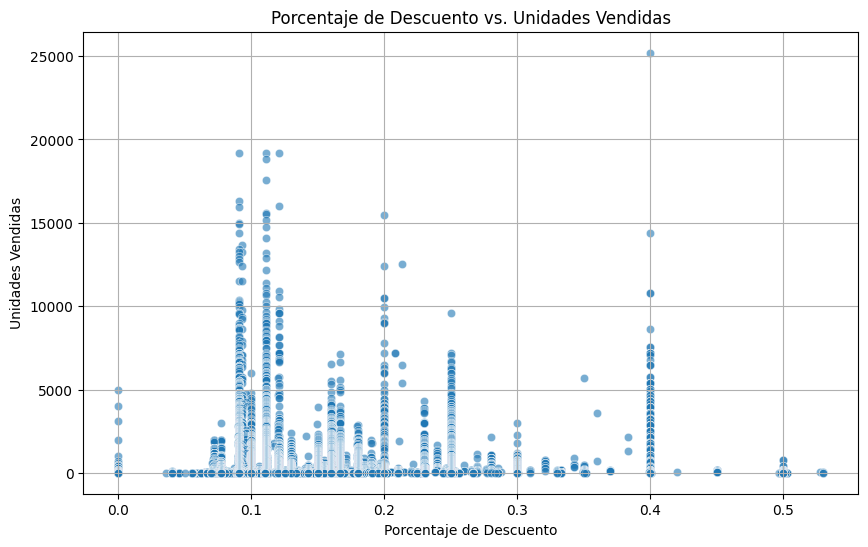

In [290]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='porcentaje_descuento', y='unidades', data=df, alpha=0.6)
plt.title('Porcentaje de Descuento vs. Unidades Vendidas')
plt.xlabel('Porcentaje de Descuento')
plt.ylabel('Unidades Vendidas')
plt.grid(True)
plt.show()

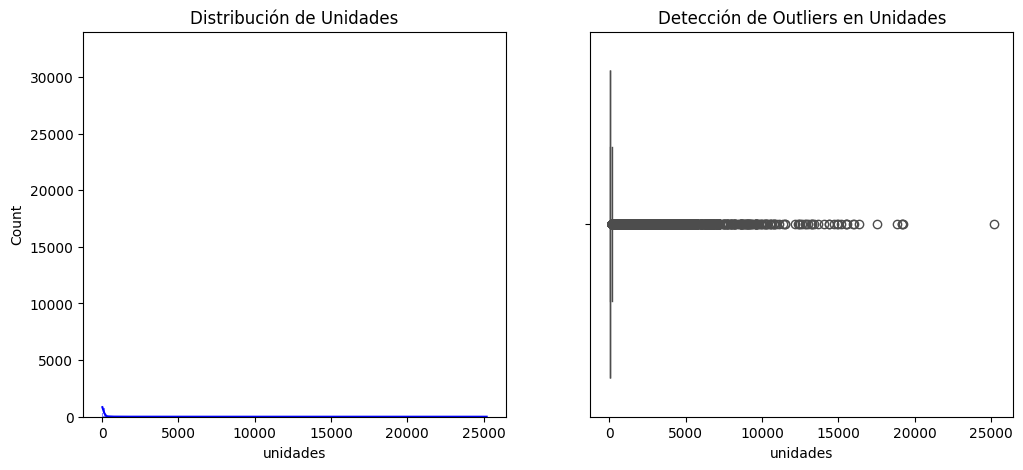

In [291]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Histograma de Ventas
plt.subplot(1, 2, 1)
sns.histplot(df['unidades'], kde=True, color='blue')
plt.title('Distribución de Unidades')

# Boxplot de Descuentos para ver Outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df['unidades'], color='red')
plt.title('Detección de Outliers en Unidades')

plt.show()

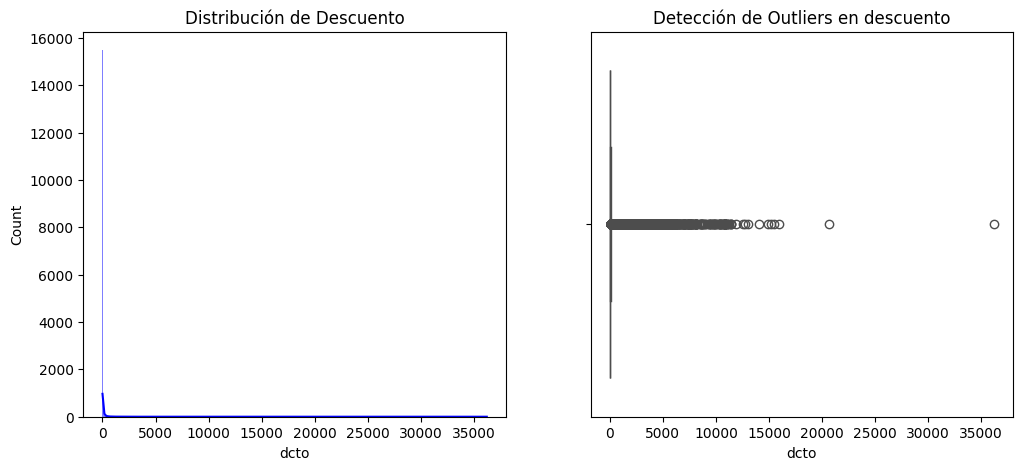

In [292]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Histograma de Ventas
plt.subplot(1, 2, 1)
sns.histplot(df['dcto'], kde=True, color='blue')
plt.title('Distribución de Descuento')

# Boxplot de Descuentos para ver Outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df['dcto'], color='red')
plt.title('Detección de Outliers en descuento')

plt.show()

### Distribución de `valor_neto`

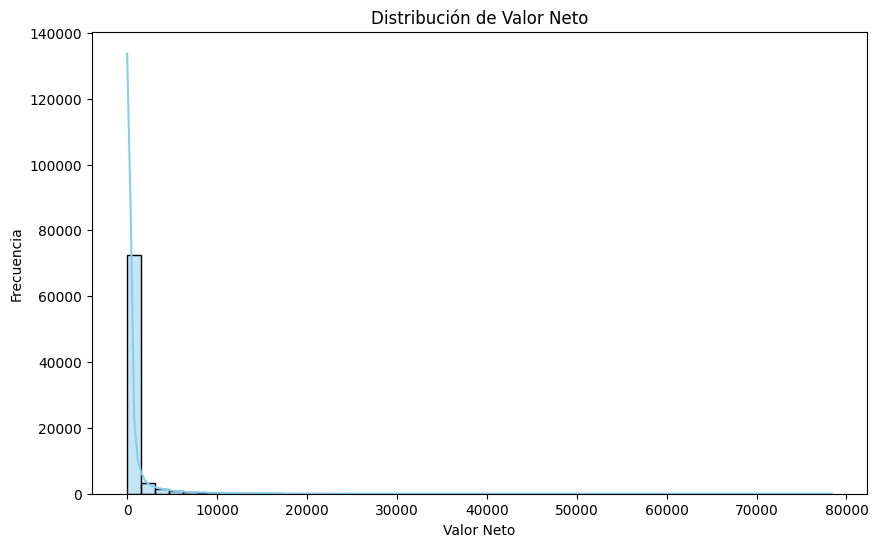

In [293]:
plt.figure(figsize=(10, 6))
sns.histplot(df['valor_neto'], kde=True, bins=50, color='skyblue')
plt.title('Distribución de Valor Neto')
plt.xlabel('Valor Neto')
plt.ylabel('Frecuencia')
plt.show()

### Boxplot de `porcentaje_descuento`

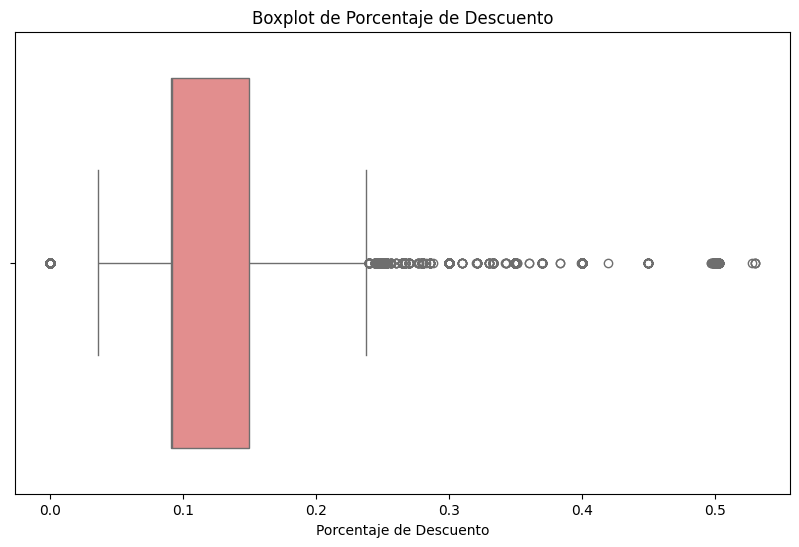

In [294]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['porcentaje_descuento'], color='lightcoral')
plt.title('Boxplot de Porcentaje de Descuento')
plt.xlabel('Porcentaje de Descuento')
plt.show()

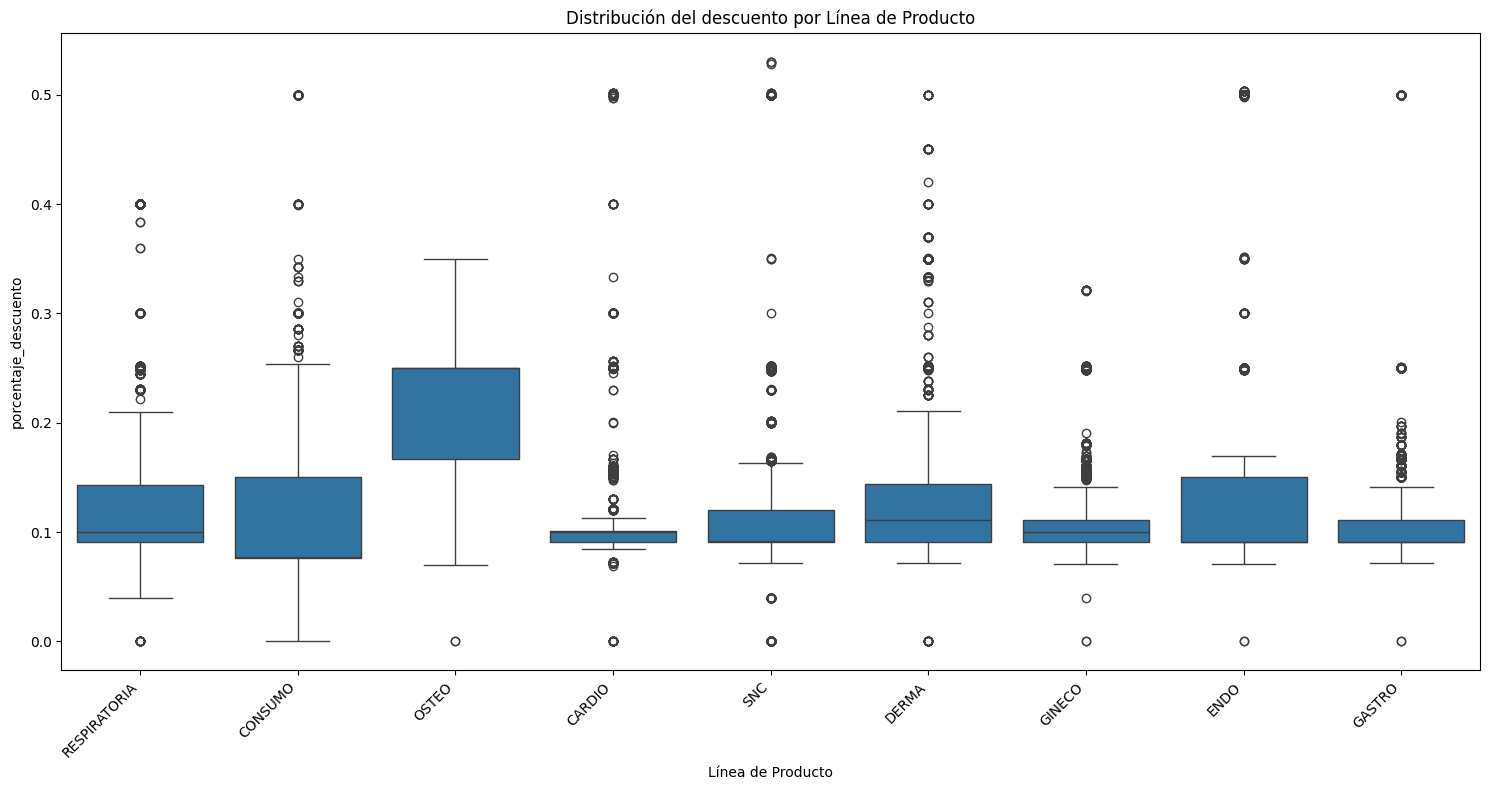

In [295]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='linea', y='porcentaje_descuento', data=df)
plt.title('Distribución del descuento por Línea de Producto')
plt.xlabel('Línea de Producto')
plt.ylabel('porcentaje_descuento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Valor Neto por `categoria`

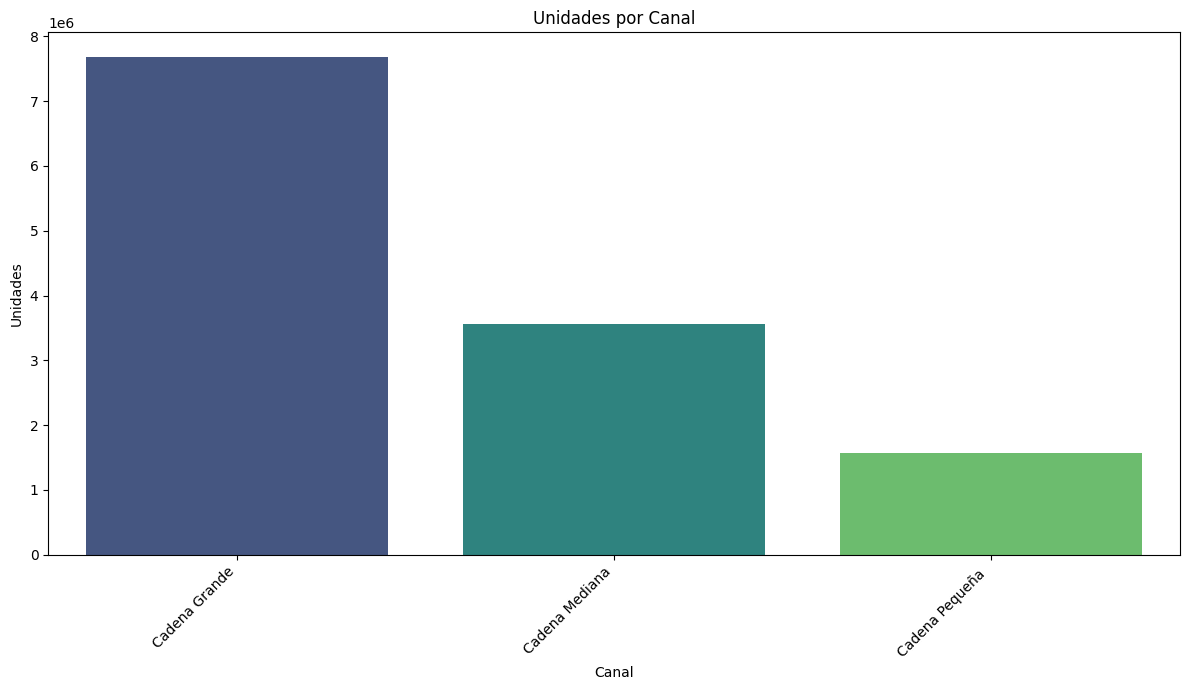

In [296]:
plt.figure(figsize=(12, 7))
sales_by_channel = df.groupby('categoria_')['unidades'].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_channel.index, y=sales_by_channel.values, palette='viridis')
plt.title('Unidades por Canal')
plt.xlabel('Canal')
plt.ylabel( 'Unidades')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

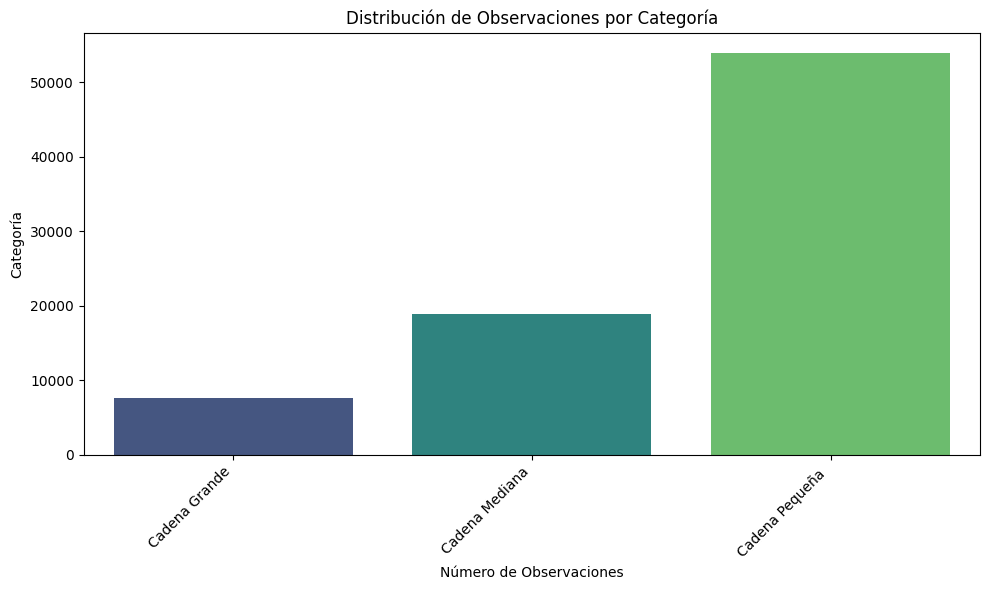

In [297]:
sales_by_channel_order = df.groupby('categoria_')['unidades'].sum().sort_values(ascending=False).index
plt.figure(figsize=(10, 6))
sns.countplot(x='categoria_', data=df, order=sales_by_channel_order, palette='viridis', hue='categoria_', legend=False)
plt.title('Distribución de Observaciones por Categoría')
plt.xlabel('Número de Observaciones')
plt.ylabel('Categoría')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

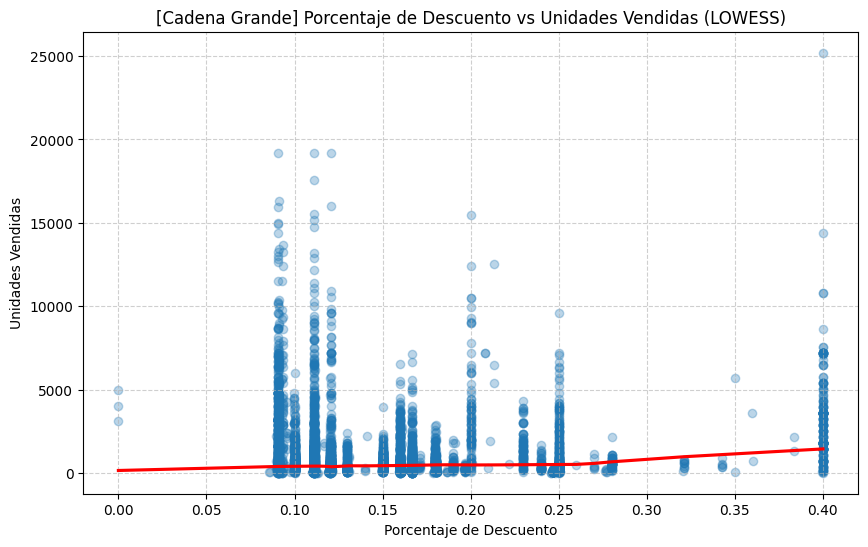

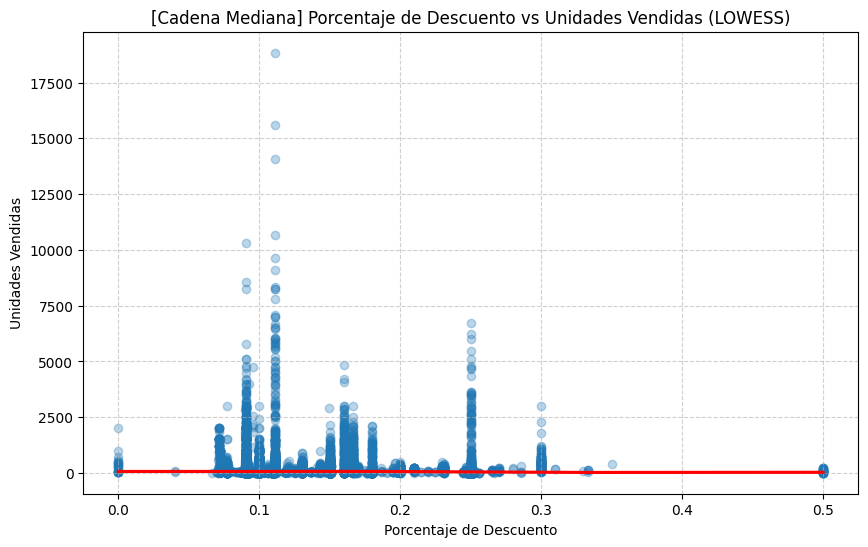

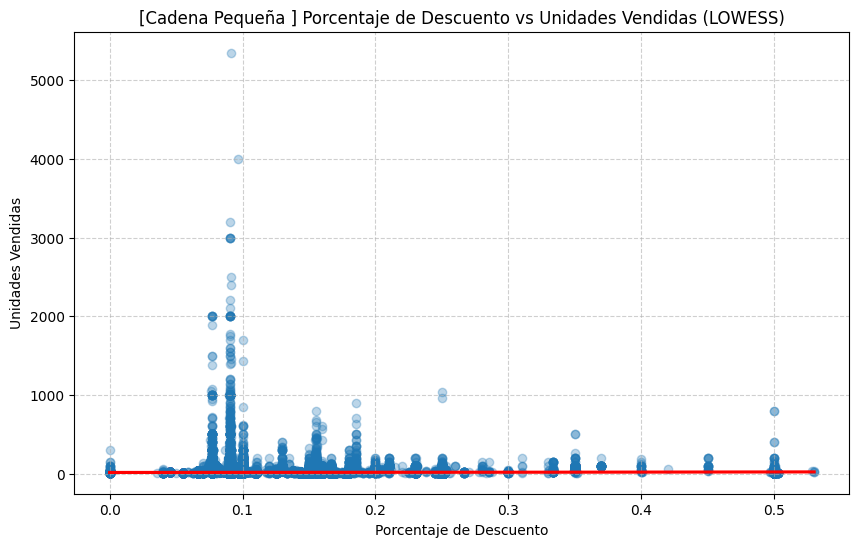

In [298]:
# Eliminar filas con valores nulos en 'categoria_' para evitar errores de agrupación
df_filtered = df.dropna(subset=['categoria_']).copy()

# Obtener los segmentos únicos
segmentos = df_filtered['categoria_'].unique()

for segmento in segmentos:
    df_segmento = df_filtered[df_filtered['categoria_'] == segmento]



    # 1. Scatter Plot (Dispersión) con LOWESS: Porcentaje de Descuento vs Unidades
    plt.figure(figsize=(10, 6))
    sns.regplot(x='porcentaje_descuento', y='unidades', data=df_segmento, lowess=True, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'[{segmento}] Porcentaje de Descuento vs Unidades Vendidas (LOWESS)')
    plt.xlabel('Porcentaje de Descuento')
    plt.ylabel('Unidades Vendidas')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

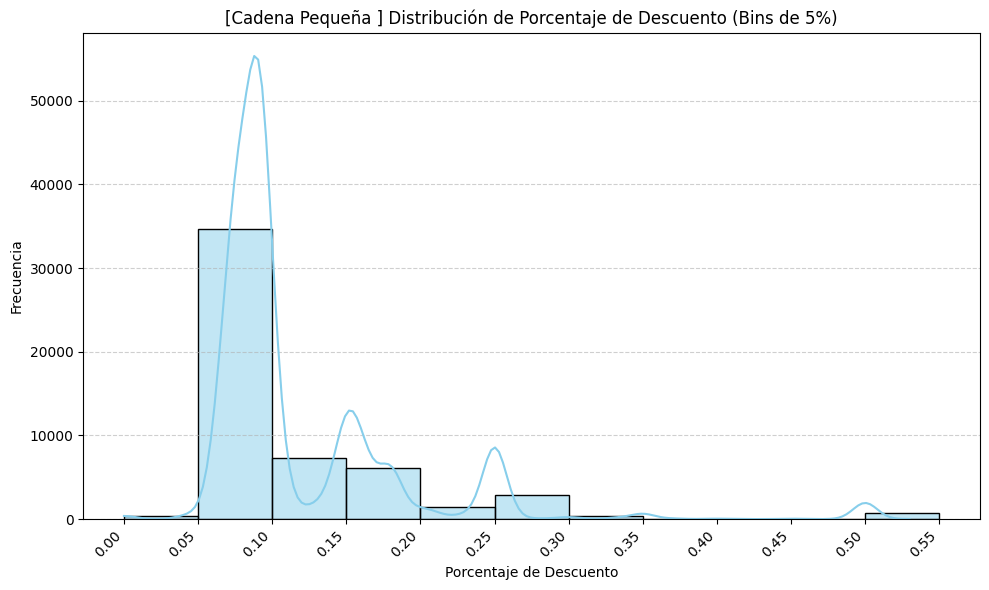

In [299]:
    # 2. Histograma de Porcentaje de Descuento en bins de 5%
    plt.figure(figsize=(10, 6))
    # Definir bins de 5% (0.05) desde 0 hasta el máximo descuento + un pequeño margen
    max_discount = df_segmento['porcentaje_descuento'].max()
    bins = np.arange(0, max_discount + 0.05, 0.05)
    sns.histplot(df_segmento['porcentaje_descuento'], bins=bins, kde=True, color='skyblue')
    plt.title(f'[{segmento}] Distribución de Porcentaje de Descuento (Bins de 5%)')
    plt.xlabel('Porcentaje de Descuento')
    plt.ylabel('Frecuencia')
    plt.xticks(bins, rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

### Mapa de Calor de Correlación entre Variables Numéricas

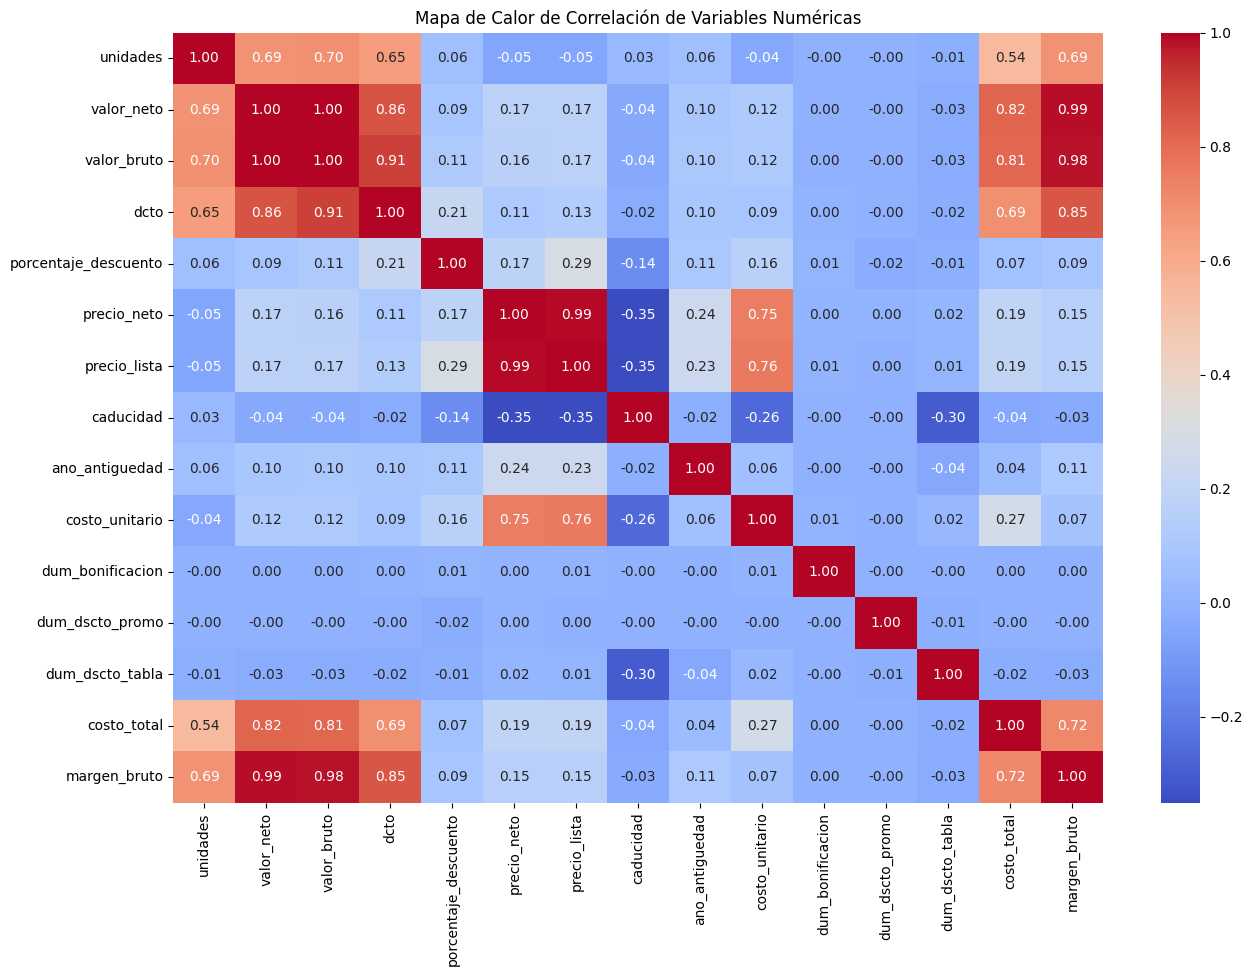

In [300]:
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlación de Variables Numéricas')
plt.show()

In [301]:
df['log_valor_neto'] = np.log1p(df['valor_neto'])
df['log_unidades'] = np.log1p(df['unidades'])

print("Primeras filas del DataFrame con las nuevas variables logarítmicas:")
display(df[['valor_neto', 'log_valor_neto', 'unidades', 'log_unidades']].head())

Primeras filas del DataFrame con las nuevas variables logarítmicas:


,valor_neto,log_valor_neto,unidades,log_unidades
0,54301.67598,10.902329,25200.0,10.134639
1,10452.65363,9.254707,19209.0,9.863186
2,10102.98484,9.220685,19200.0,9.862718
3,61210.66241,11.022093,19174.0,9.861363
4,63148.27614,11.053257,18839.0,9.843738


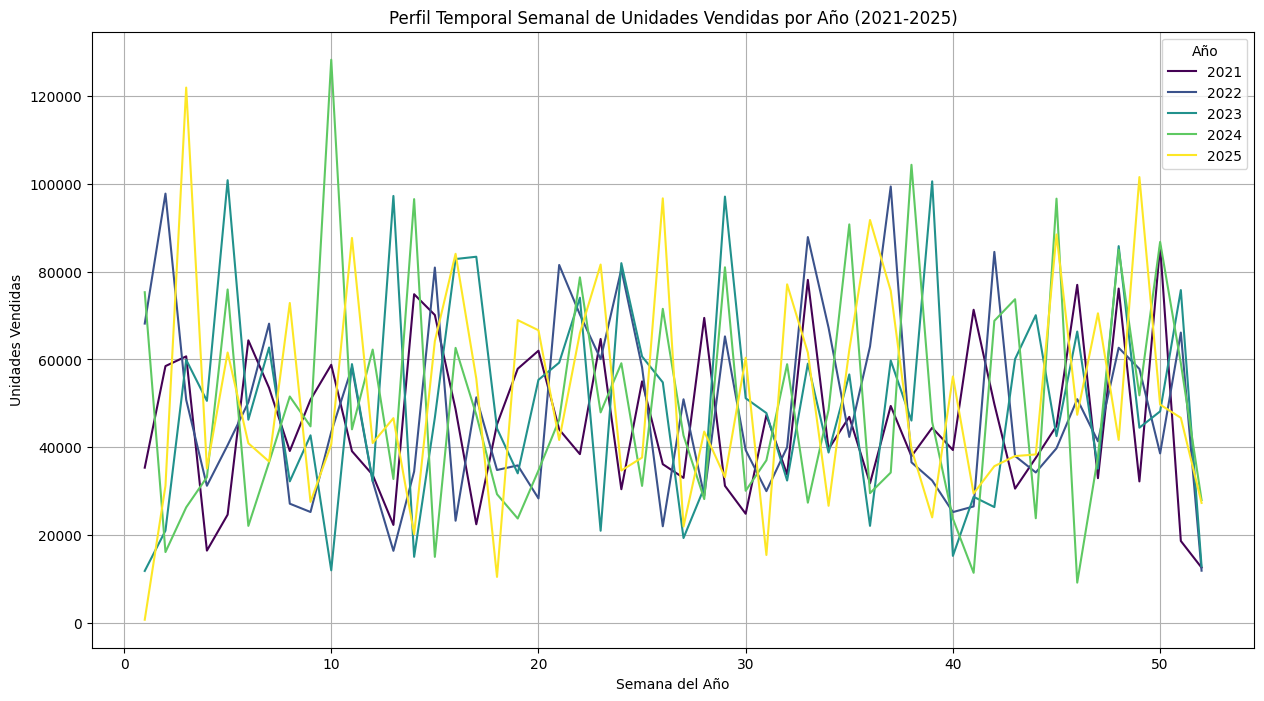

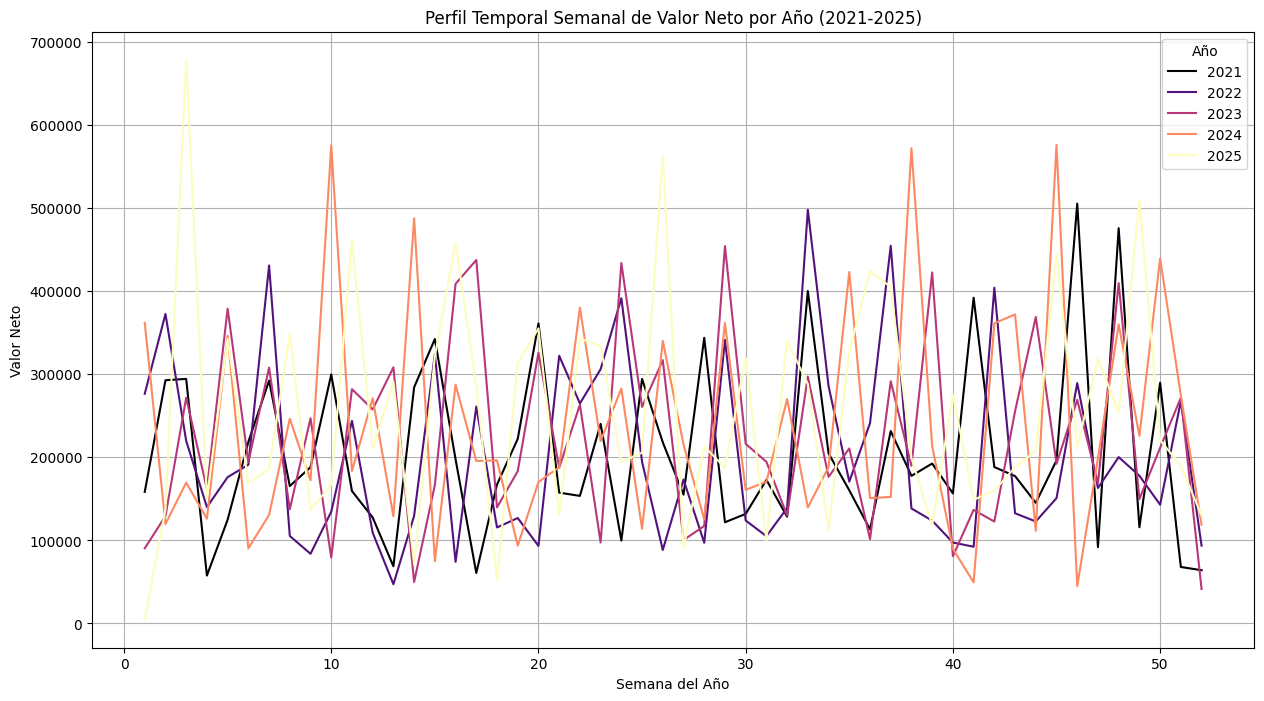

Primeras filas del perfil semanal:


,year,weekofyear,unidades_sum,valor_neto_sum
0,2021,1,35346.0,158413.008777
1,2021,2,58480.0,292836.791703
2,2021,3,60693.0,294421.787720
3,2021,4,16463.0,57695.131683
4,2021,5,24649.0,124937.749407


In [302]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que 'fecha' sea datetime y crear 'year' y 'weekofyear'
df['fecha'] = pd.to_datetime(df['fecha'])
df['year'] = df['fecha'].dt.year
df['weekofyear'] = df['fecha'].dt.isocalendar().week.astype(int)

# Filtrar años si es necesario, aunque el rango ya está establecido (2021-2025)
df_filtered_years = df[(df['year'] >= 2021) & (df['year'] <= 2025)]

# Agrupar por año y semana para obtener el perfil temporal
weekly_profile = df_filtered_years.groupby(['year', 'weekofyear']).agg(
    unidades_sum=('unidades', 'sum'),
    valor_neto_sum=('valor_neto', 'sum')
).reset_index()

# Visualizar el perfil de unidades con gráficos de línea
plt.figure(figsize=(15, 8))
sns.lineplot(data=weekly_profile, x='weekofyear', y='unidades_sum', hue='year', palette='viridis')
plt.title('Perfil Temporal Semanal de Unidades Vendidas por Año (2021-2025)')
plt.xlabel('Semana del Año')
plt.ylabel('Unidades Vendidas')
plt.legend(title='Año')
plt.grid(True)
plt.show()

# Visualizar el perfil de valor_neto con gráficos de línea
plt.figure(figsize=(15, 8))
sns.lineplot(data=weekly_profile, x='weekofyear', y='valor_neto_sum', hue='year', palette='magma')
plt.title('Perfil Temporal Semanal de Valor Neto por Año (2021-2025)')
plt.xlabel('Semana del Año')
plt.ylabel('Valor Neto')
plt.legend(title='Año')
plt.grid(True)
plt.show()

print("Primeras filas del perfil semanal:")
display(weekly_profile.head())



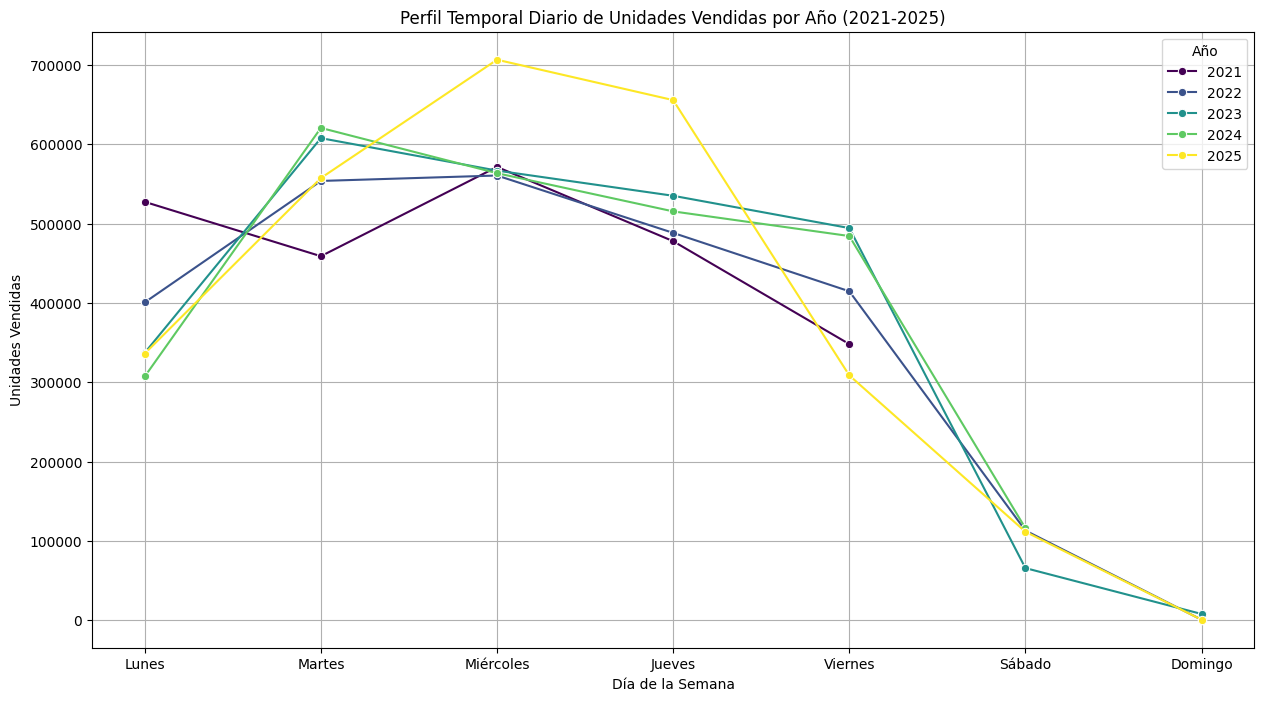

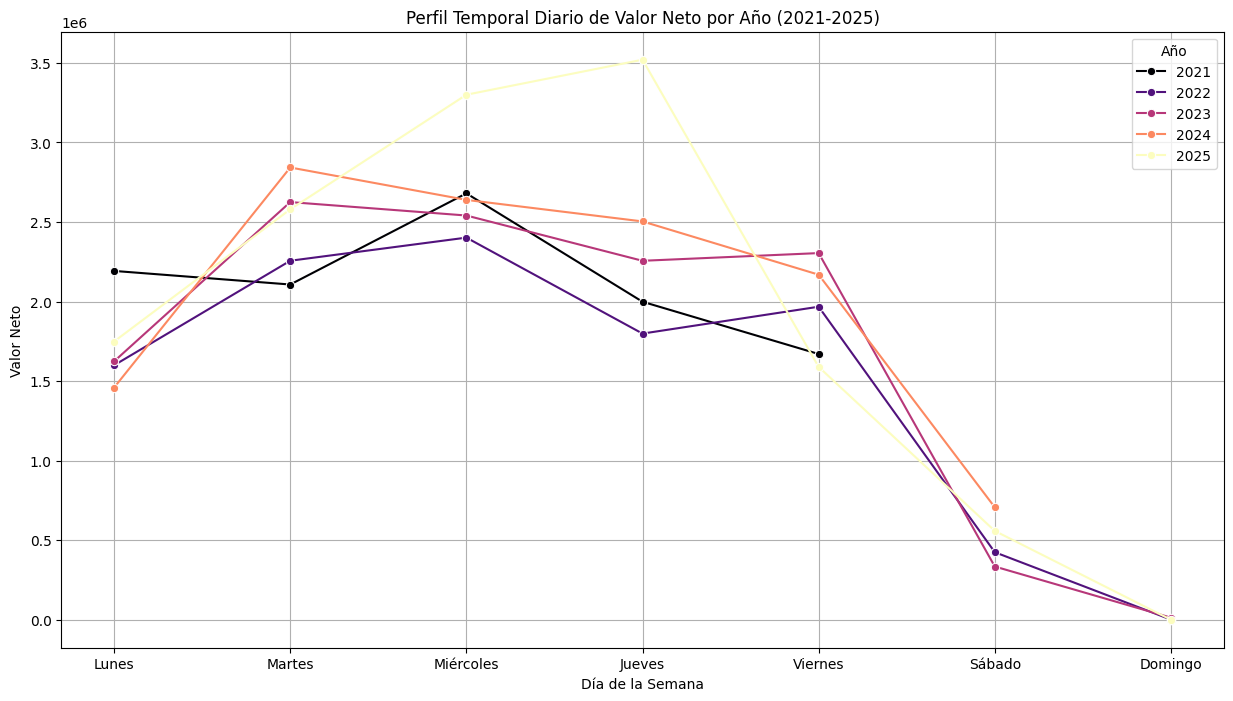

Primeras filas del perfil diario semanal:


,year,dayofweek,unidades_sum,valor_neto_sum,day_name
0,2021,0,527443.0,2.192730e+06,Lunes
1,2021,1,458926.0,2.107354e+06,Martes
2,2021,2,571497.0,2.680038e+06,Miércoles
3,2021,3,477880.0,1.999110e+06,Jueves
4,2021,4,348109.0,1.670651e+06,Viernes


In [303]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que 'fecha' sea datetime y crear 'year' y 'dayofweek'
df['fecha'] = pd.to_datetime(df['fecha'])
df['year'] = df['fecha'].dt.year
df['dayofweek'] = df['fecha'].dt.dayofweek # Lunes=0, Domingo=6

# Filtrar años si es necesario, aunque el rango ya está establecido (2021-2025)
df_filtered_years = df[(df['year'] >= 2021) & (df['year'] <= 2025)]

# Agrupar por año y día de la semana para obtener el perfil temporal
daily_weekly_profile = df_filtered_years.groupby(['year', 'dayofweek']).agg(
    unidades_sum=('unidades', 'sum'),
    valor_neto_sum=('valor_neto', 'sum')
).reset_index()

# Mapear números de día a nombres para una mejor visualización
day_names = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
daily_weekly_profile['day_name'] = daily_weekly_profile['dayofweek'].map(lambda x: day_names[x])

# Visualizar el perfil de unidades por día de la semana y año
plt.figure(figsize=(15, 8))
sns.lineplot(data=daily_weekly_profile, x='day_name', y='unidades_sum', hue='year', palette='viridis', marker='o')
plt.title('Perfil Temporal Diario de Unidades Vendidas por Año (2021-2025)')
plt.xlabel('Día de la Semana')
plt.ylabel('Unidades Vendidas')
plt.legend(title='Año')
plt.grid(True)
plt.show()

# Visualizar el perfil de valor_neto por día de la semana y año
plt.figure(figsize=(15, 8))
sns.lineplot(data=daily_weekly_profile, x='day_name', y='valor_neto_sum', hue='year', palette='magma', marker='o')
plt.title('Perfil Temporal Diario de Valor Neto por Año (2021-2025)')
plt.xlabel('Día de la Semana')
plt.ylabel('Valor Neto')
plt.legend(title='Año')
plt.grid(True)
plt.show()

print("Primeras filas del perfil diario semanal:")
display(daily_weekly_profile.head())

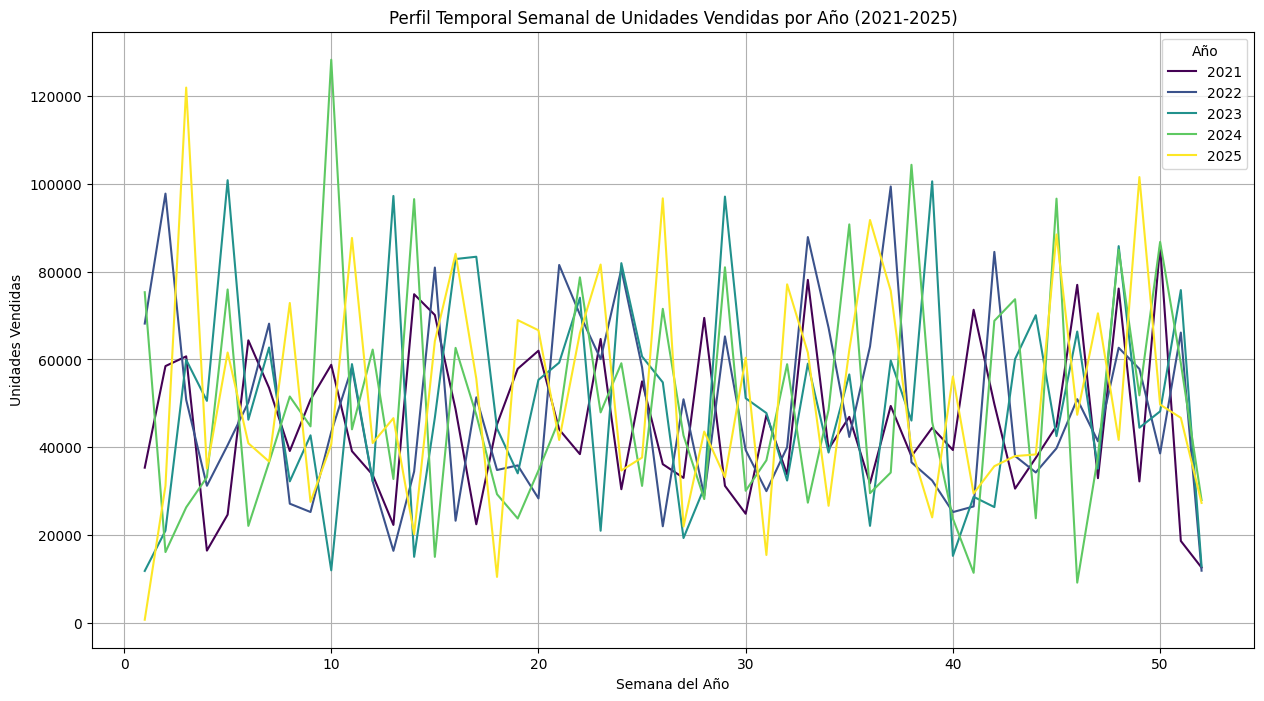

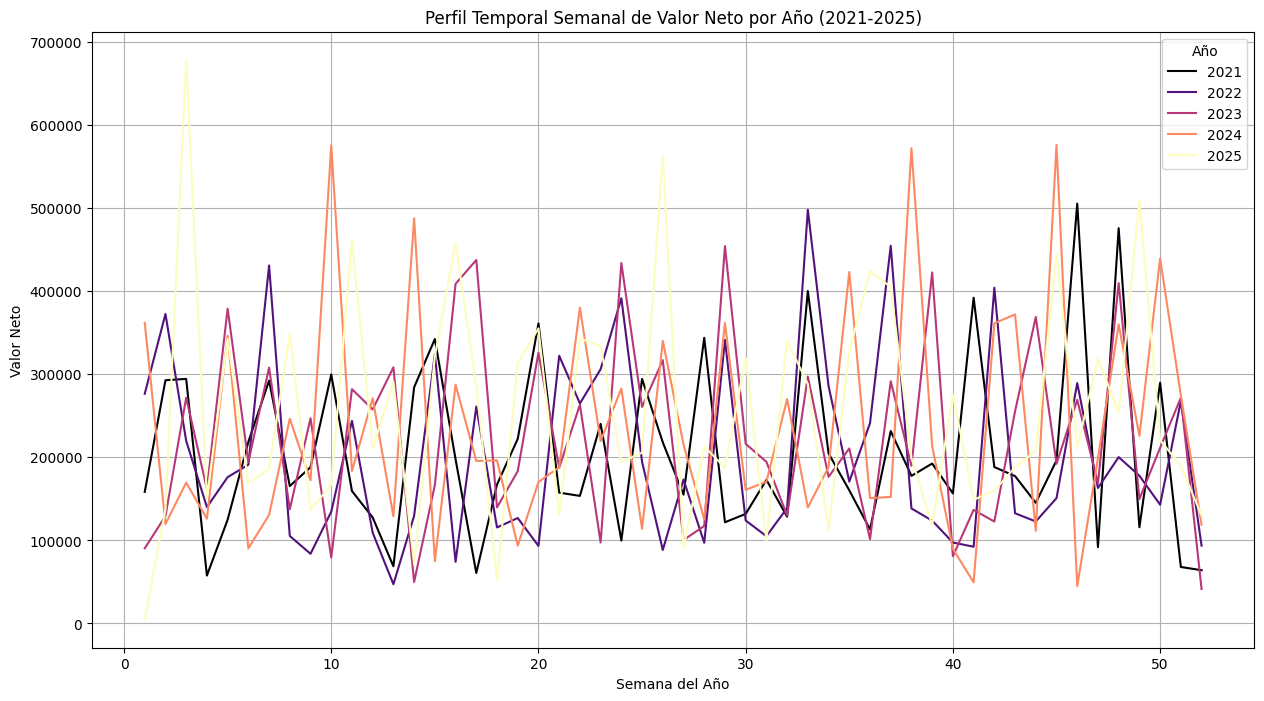

Primeras filas del perfil semanal:


,year,weekofyear,unidades_sum,valor_neto_sum
0,2021,1,35346.0,158413.008777
1,2021,2,58480.0,292836.791703
2,2021,3,60693.0,294421.787720
3,2021,4,16463.0,57695.131683
4,2021,5,24649.0,124937.749407


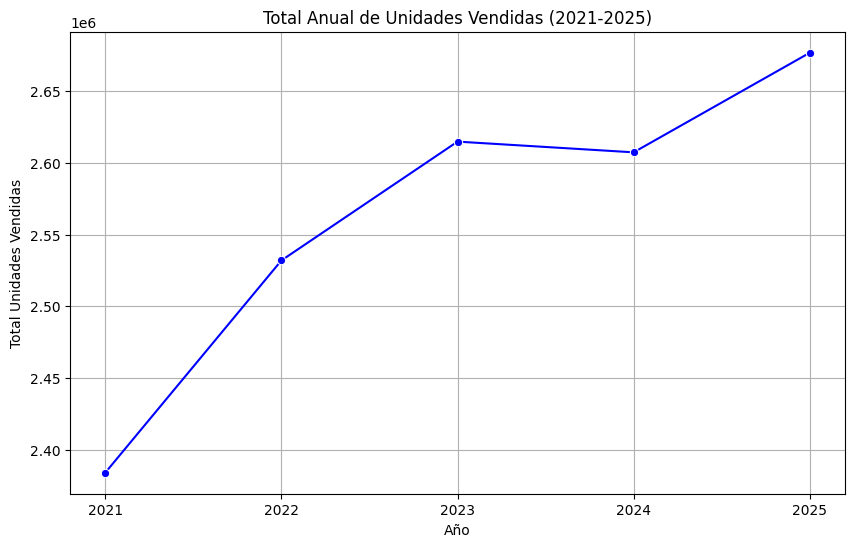

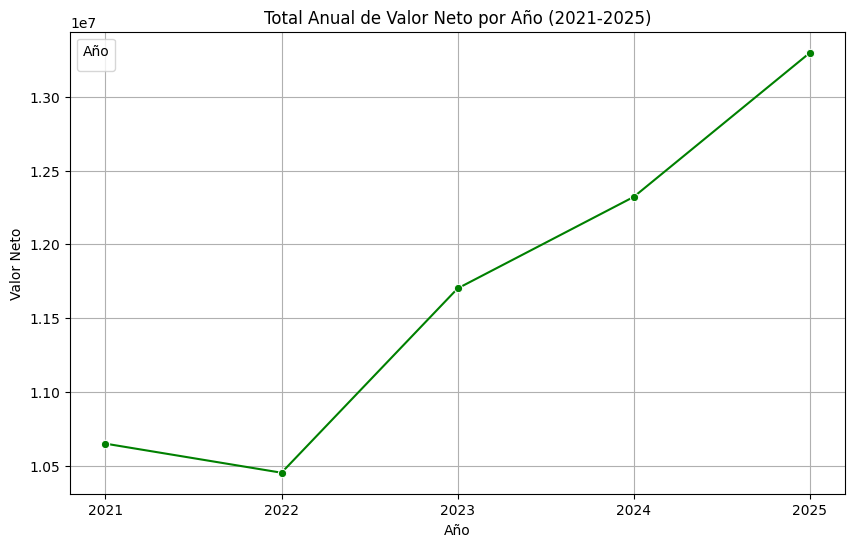

Primeras filas del resumen anual:


,year,total_unidades,total_valor_neto
0,2021,2383855.0,1.064988e+07
1,2022,2531899.0,1.045284e+07
2,2023,2614801.0,1.170166e+07
3,2024,2607324.0,1.232202e+07
4,2025,2676802.0,1.329865e+07


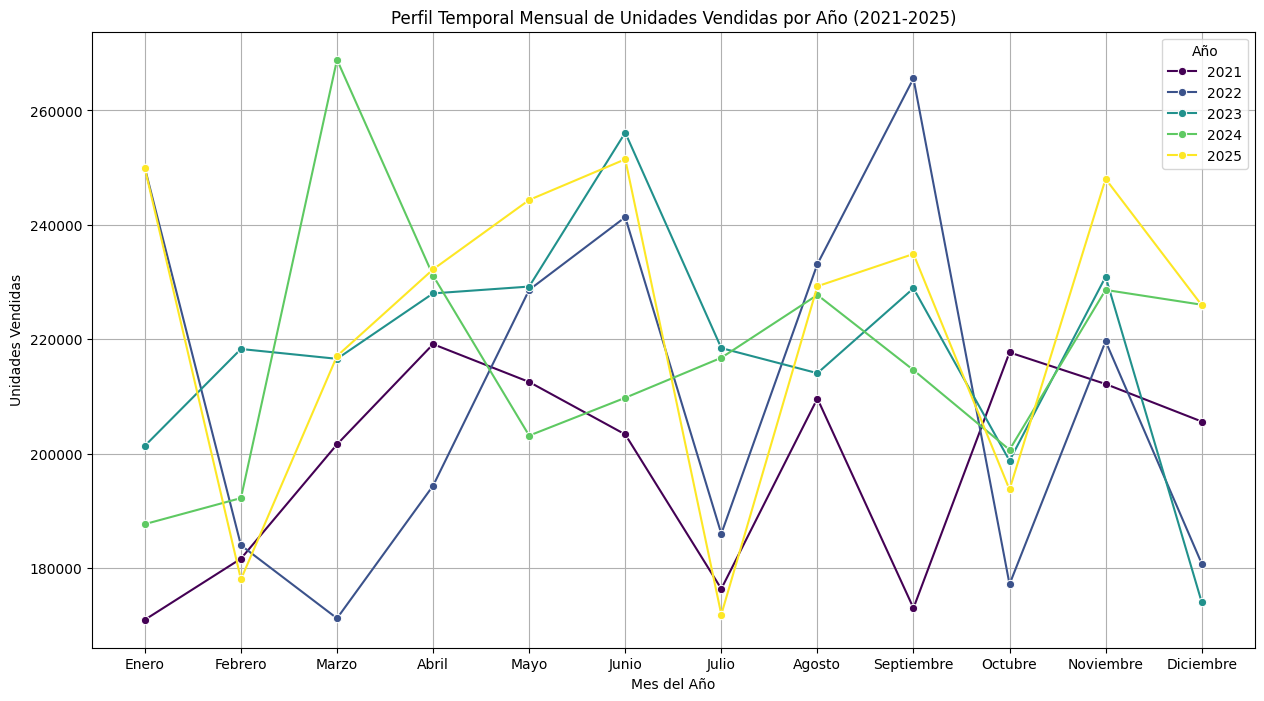

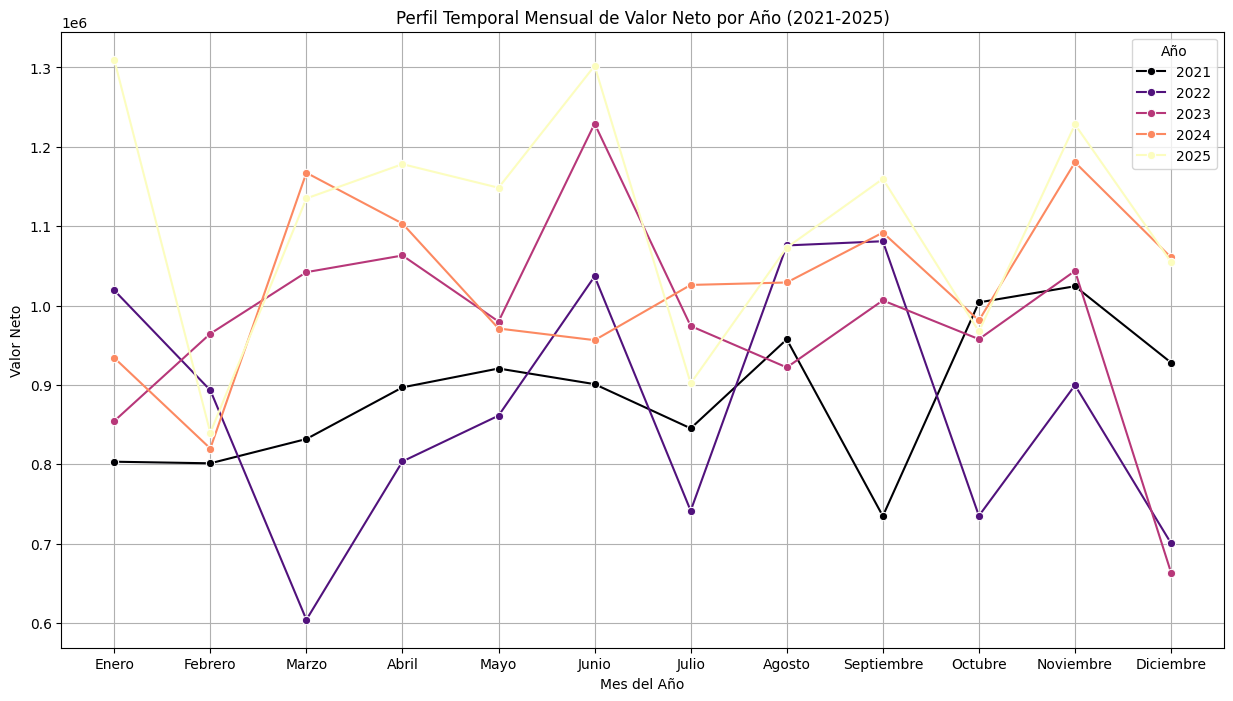

Primeras filas del perfil mensual:


,year,month,unidades_sum,valor_neto_sum,month_name
0,2021,1,170982.0,803366.719883,Enero
1,2021,2,181653.0,801357.142846,Febrero
2,2021,3,201627.0,831968.076623,Marzo
3,2021,4,219145.0,897004.389464,Abril
4,2021,5,212535.0,920759.776524,Mayo


In [304]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que 'fecha' sea datetime y crear 'year', 'month' y 'weekofyear'
df['fecha'] = pd.to_datetime(df['fecha'])
df['year'] = df['fecha'].dt.year
df['month'] = df['fecha'].dt.month # Extracción del mes
df['weekofyear'] = df['fecha'].dt.isocalendar().week.astype(int)

# Filtrar años si es necesario, aunque el rango ya está establecido (2021-2025)
df_filtered_years = df[(df['year'] >= 2021) & (df['year'] <= 2025)]

# Agrupar por año y semana para obtener el perfil temporal
weekly_profile = df_filtered_years.groupby(['year', 'weekofyear']).agg(
    unidades_sum=('unidades', 'sum'),
    valor_neto_sum=('valor_neto', 'sum')
).reset_index()

# Visualizar el perfil de unidades con gráficos de línea
plt.figure(figsize=(15, 8))
sns.lineplot(data=weekly_profile, x='weekofyear', y='unidades_sum', hue='year', palette='viridis')
plt.title('Perfil Temporal Semanal de Unidades Vendidas por Año (2021-2025)')
plt.xlabel('Semana del Año')
plt.ylabel('Unidades Vendidas')
plt.legend(title='Año')
plt.grid(True)
plt.show()

# Visualizar el perfil de valor_neto con gráficos de línea
plt.figure(figsize=(15, 8))
sns.lineplot(data=weekly_profile, x='weekofyear', y='valor_neto_sum', hue='year', palette='magma')
plt.title('Perfil Temporal Semanal de Valor Neto por Año (2021-2025)')
plt.xlabel('Semana del Año')
plt.ylabel('Valor Neto')
plt.legend(title='Año')
plt.grid(True)
plt.show()

print("Primeras filas del perfil semanal:")
display(weekly_profile.head())


# Generar el perfil anual (total por año)
annual_summary = df_filtered_years.groupby('year').agg(
    total_unidades=('unidades', 'sum'),
    total_valor_neto=('valor_neto', 'sum')
).reset_index()

# Visualizar el perfil anual de unidades
plt.figure(figsize=(10, 6))
sns.lineplot(data=annual_summary, x='year', y='total_unidades', marker='o', color='blue')
plt.title('Total Anual de Unidades Vendidas (2021-2025)')
plt.xlabel('Año')
plt.ylabel('Total Unidades Vendidas')
plt.grid(True)
plt.xticks(annual_summary['year'])
plt.show()

# Visualizar el perfil anual de valor neto
plt.figure(figsize=(10, 6))
sns.lineplot(data=annual_summary, x='year', y='total_valor_neto', marker='o', color='green')
plt.title('Total Anual de Valor Neto por Año (2021-2025)')
plt.xlabel('Año')
plt.ylabel('Valor Neto')
plt.legend(title='Año')
plt.grid(True)
plt.xticks(annual_summary['year'])
plt.show()

print("Primeras filas del resumen anual:")
display(annual_summary.head())


# Generar el perfil mensual (total por mes dentro de cada año)
monthly_profile = df_filtered_years.groupby(['year', 'month']).agg(
    unidades_sum=('unidades', 'sum'),
    valor_neto_sum=('valor_neto', 'sum')
).reset_index()

# Mapear números de mes a nombres para una mejor visualización
month_names = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
    7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
monthly_profile['month_name'] = monthly_profile['month'].map(lambda x: month_names[x])

# Visualizar el perfil mensual de unidades
plt.figure(figsize=(15, 8))
sns.lineplot(data=monthly_profile, x='month_name', y='unidades_sum', hue='year', palette='viridis', marker='o')
plt.title('Perfil Temporal Mensual de Unidades Vendidas por Año (2021-2025)')
plt.xlabel('Mes del Año')
plt.ylabel('Unidades Vendidas')
plt.legend(title='Año')
plt.grid(True)
plt.show()

# Visualizar el perfil mensual de valor neto
plt.figure(figsize=(15, 8))
sns.lineplot(data=monthly_profile, x='month_name', y='valor_neto_sum', hue='year', palette='magma', marker='o')
plt.title('Perfil Temporal Mensual de Valor Neto por Año (2021-2025)')
plt.xlabel('Mes del Año')
plt.ylabel('Valor Neto')
plt.legend(title='Año')
plt.grid(True)
plt.show()

print("Primeras filas del perfil mensual:")
display(monthly_profile.head())

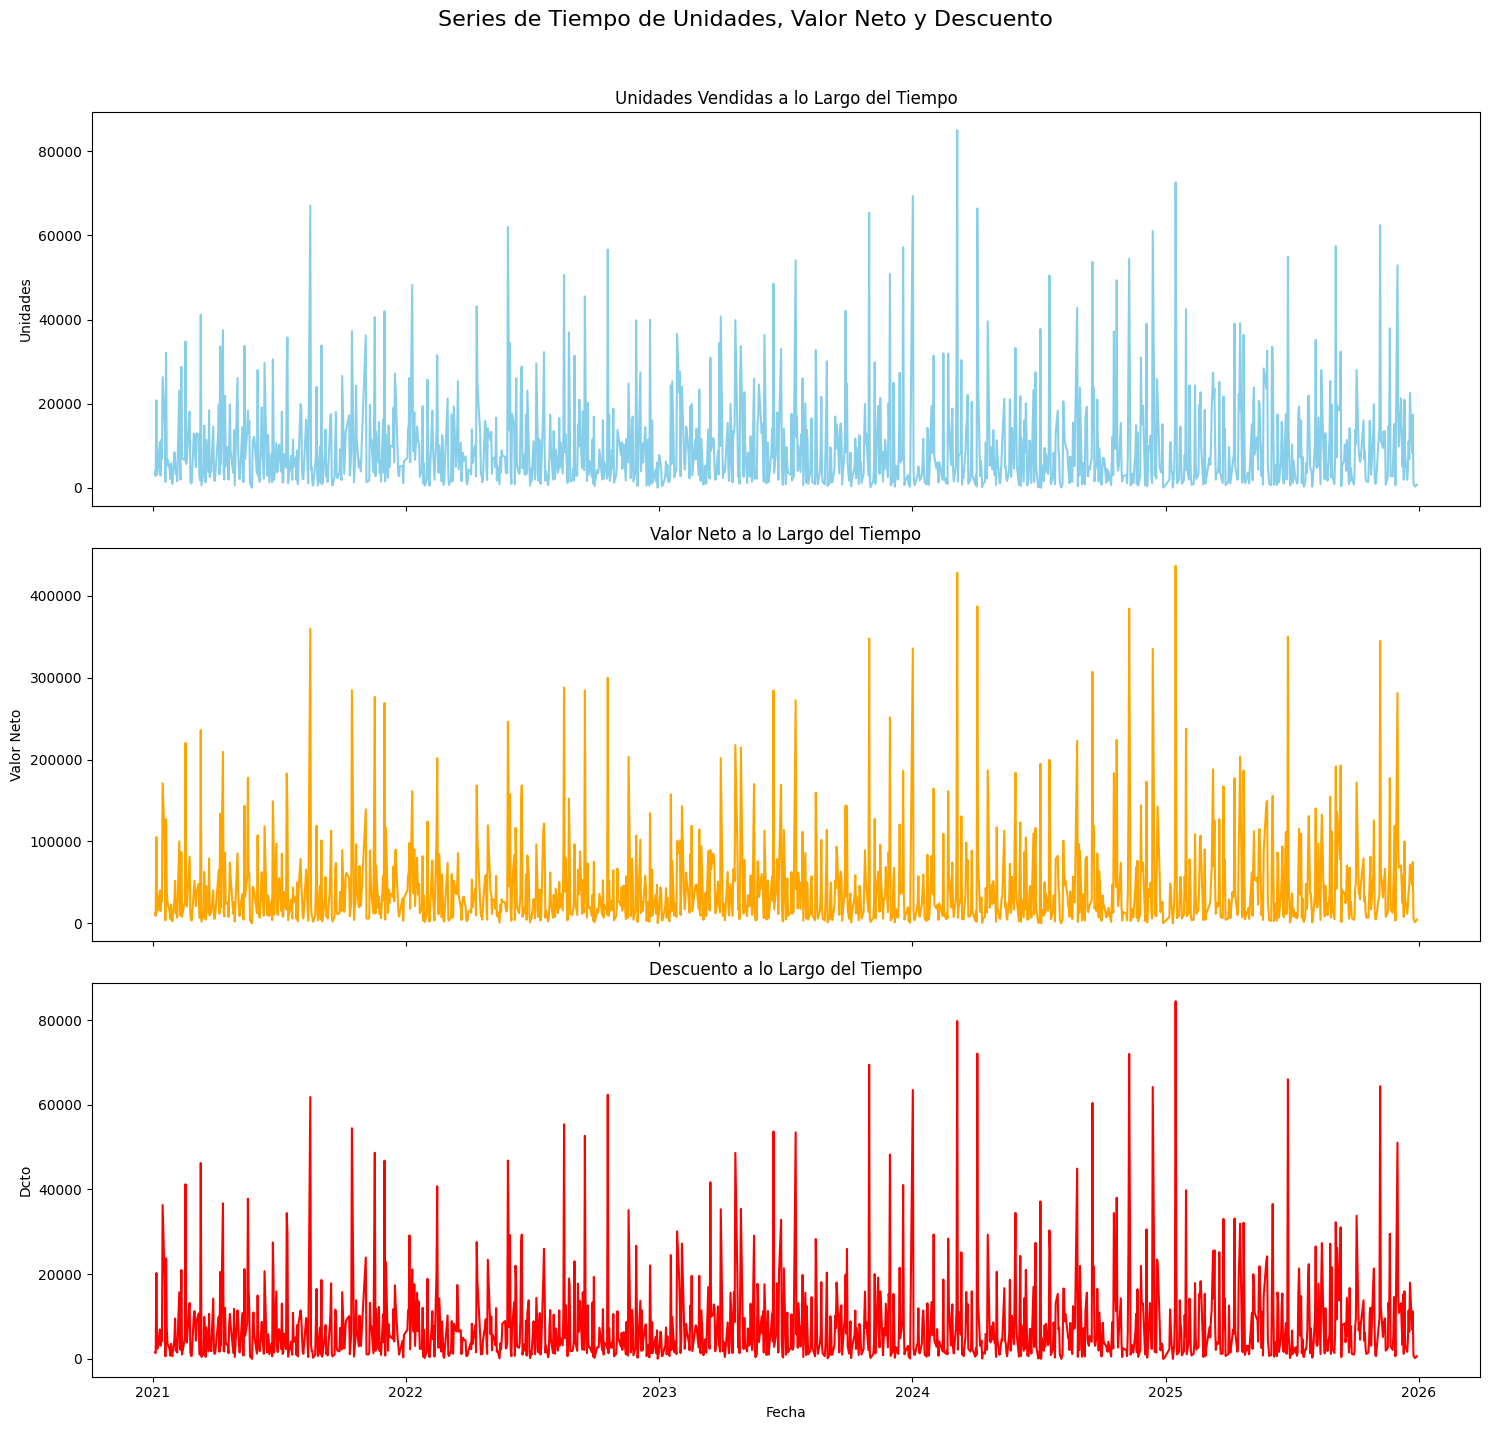

In [305]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar los datos por fecha y sumar las columnas de interés
df_time_series = df.groupby('fecha')[['unidades', 'valor_neto', 'dcto']].sum().reset_index()

# Crear los gráficos de series de tiempo
fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=True) # Cambiado a 3 subplots
fig.suptitle('Series de Tiempo de Unidades, Valor Neto y Descuento', fontsize=16)

# Gráfico para 'unidades'
sns.lineplot(ax=axes[0], x='fecha', y='unidades', data=df_time_series, color='skyblue')
axes[0].set_title('Unidades Vendidas a lo Largo del Tiempo')
axes[0].set_ylabel('Unidades')

# Gráfico para 'valor_neto'
sns.lineplot(ax=axes[1], x='fecha', y='valor_neto', data=df_time_series, color='orange')
axes[1].set_title('Valor Neto a lo Largo del Tiempo')
axes[1].set_ylabel('Valor Neto')

# Gráfico para 'dcto'
sns.lineplot(ax=axes[2], x='fecha', y='dcto', data=df_time_series, color='red') # Cambiado a axes[2]
axes[2].set_title('Descuento a lo Largo del Tiempo')
axes[2].set_ylabel('Dcto')
axes[2].set_xlabel('Fecha')

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Ajustar layout para evitar superposición con el título principal
plt.show()

In [306]:
display(df_time_series.describe())

,fecha,unidades,valor_neto,dcto
count,1278,1278.000000,1278.000000,1278.000000
mean,2023-07-07 02:03:56.619718400,10027.136933,45716.002014,8337.265330
min,2021-01-04 00:00:00,20.000000,18.268156,1.524342
25%,2022-04-18 06:00:00,2539.750000,10826.250998,1811.552274
50%,2023-07-08 00:00:00,5997.500000,26536.713886,4418.465682
75%,2024-09-26 18:00:00,13739.250000,58801.356744,10918.222267
max,2025-12-29 00:00:00,85027.000000,436915.526742,84432.605741
std,NaN,11115.447292,56369.646781,10548.630246


In [307]:
window_size = 7

# 1. Calcular la media móvil
df_time_series['rolling_mean'] = df_time_series['unidades'].rolling(window=window_size).mean()

# 2. Calcular la desviación estándar móvil
df_time_series['rolling_std'] = df_time_series['unidades'].rolling(window=window_size).std()

# 3. Definir los límites superior e inferior para la detección de anomalías
df_time_series['upper_bound'] = df_time_series['rolling_mean'] + (df_time_series['rolling_std'] * 3)
df_time_series['lower_bound'] = df_time_series['rolling_mean'] - (df_time_series['rolling_std'] * 3)

# 4. Identificar los puntos de datos anómalos
df_time_series['anomaly'] = np.where(
    (df_time_series['unidades'] > df_time_series['upper_bound']) |
    (df_time_series['unidades'] < df_time_series['lower_bound']),
    df_time_series['unidades'], np.nan
)

print("Primeras filas de df_time_series con las nuevas columnas:")
display(df_time_series.head(20))
print("Estadísticas descriptivas de las nuevas columnas:")
display(df_time_series[['unidades', 'rolling_mean', 'rolling_std', 'upper_bound', 'lower_bound', 'anomaly']].describe())

Primeras filas de df_time_series con las nuevas columnas:


,fecha,unidades,valor_neto,dcto,rolling_mean,rolling_std,upper_bound,lower_bound,anomaly
0,2021-01-04,3836.0,12043.894652,1496.807662,NaN,NaN,NaN,NaN,NaN
1,2021-01-05,2809.0,9088.986433,1375.498803,NaN,NaN,NaN,NaN,NaN
2,2021-01-06,20839.0,105388.667199,20270.151636,NaN,NaN,NaN,NaN,NaN
3,2021-01-07,3216.0,13957.302474,2346.767758,NaN,NaN,NaN,NaN,NaN
4,2021-01-08,4646.0,17934.158020,2654.828412,NaN,NaN,NaN,NaN,NaN
5,2021-01-11,10898.0,40280.526736,6956.504389,NaN,NaN,NaN,NaN,NaN
6,2021-01-12,2909.0,15033.519553,3128.092578,7021.857143,6719.134504,27179.260653,-13135.546368,NaN
7,2021-01-13,11406.0,39677.174778,6286.512370,8103.285714,6730.096822,28293.576181,-12087.004753,NaN
8,2021-01-14,6931.0,26767.757382,4161.213089,8692.142857,6359.805328,27771.558841,-10387.273127,NaN
9,2021-01-15,26336.0,171077.813254,36312.450121,9477.428571,8186.631213,34037.322211,-15082.465068,NaN


Estadísticas descriptivas de las nuevas columnas:


,unidades,rolling_mean,rolling_std,upper_bound,lower_bound,anomaly
count,1278.000000,1272.000000,1272.000000,1272.000000,1272.000000,0.0
mean,10027.136933,10046.047507,10045.971004,40183.960519,-20091.865505,NaN
std,11115.447292,3695.917290,5246.296346,18833.613199,12963.019691,NaN
min,20.000000,2381.571429,1376.153663,6959.746704,-72584.630428,NaN
25%,2539.750000,7222.714286,6231.776413,26805.976353,-26559.140301,NaN
50%,5997.500000,9648.642857,8878.879438,36450.567562,-17063.952209,NaN
75%,13739.250000,12568.964286,12891.207142,50675.287262,-10856.918686,NaN
max,85027.000000,23810.142857,30672.591095,112722.606719,397.594488,NaN


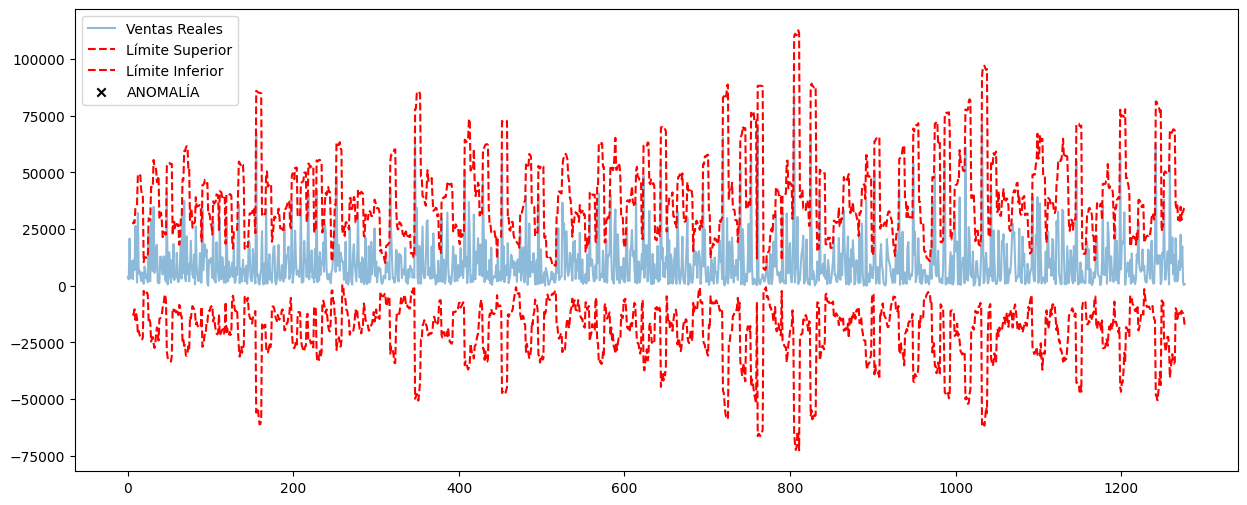

In [308]:
plt.figure(figsize=(15, 6))
plt.plot(df_time_series['unidades'], label='Ventas Reales', alpha=0.5)
plt.plot(df_time_series['upper_bound'], label='Límite Superior', color='red', linestyle='--')
plt.plot(df_time_series['lower_bound'], label='Límite Inferior', color='red', linestyle='--')
plt.scatter(df_time_series.index, df_time_series['anomaly'], color='black', label='ANOMALÍA', marker='x')
plt.legend()
plt.show()

In [309]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def prepare_cross_elasticity_data(df, segmento=None):
    if segmento:
        df = df[df['categoría_'] == segmento]

    # Crear una tabla pivote de precios netos por fecha
    price_pivot = df.pivot_table(index='fecha', columns='nombre_anonimizado', values='precio_neto', aggfunc='mean')

    # Crear una tabla pivote de unidades vendidas por fecha
    units_pivot = df.pivot_table(index='fecha', columns='nombre_anonimizado', values='unidades', aggfunc='sum').fillna(0)

    return price_pivot, units_pivot

price_df, units_df = prepare_cross_elasticity_data(df)

**Descomposición de series de tiempo**

In [310]:
from statsmodels.tsa.seasonal import seasonal_decompose

def extract_time_features(df_group):
    # Agrupar por fecha y sumar unidades, promediar el porcentaje_descuento
    # para asegurar un índice de fecha único.
    df_group = df_group.groupby('fecha').agg({
        'unidades': 'sum',
        'porcentaje_descuento': 'mean'
    }).reset_index()

    # Asegurar que la fecha sea el índice y tenga frecuencia diaria
    df_group = df_group.set_index('fecha').asfreq('D')

    # Rellenar los valores NaN (días sin ventas) con 0 para unidades y porcentaje_descuento
    df_group['unidades'] = df_group['unidades'].fillna(0)
    df_group['porcentaje_descuento'] = df_group['porcentaje_descuento'].fillna(df_group['porcentaje_descuento'].mean())

    # Descomposición (periodo=7 para semanal o 30 para mensual)
    # Esto genera la variable que usarás como Beta 1
    # Comprobar si hay suficientes datos para la descomposición estacional
    if len(df_group) < 14:
        print("No hay suficientes observaciones para la descomposición estacional (se requieren al menos 14). Retornando DataFrame sin estacionalidad/tendencia.")
        df_group['estacionalidad'] = 0  # o np.nan
        df_group['tendencia'] = df_group['unidades'] # si no hay tendencia, la unidad es la tendencia
        return df_group.reset_index()

    analysis = seasonal_decompose(df_group['unidades'], model='additive', period=7)

    df_group['estacionalidad'] = analysis.seasonal
    df_group['tendencia'] = analysis.trend.fillna(method='bfill').fillna(method='ffill')

    return df_group.reset_index()

In [311]:
def train_predictive_model(df, prod_id, cliente_tipo):
    # Filtramos por tu unidad de análisis
    subset = df[(df['id_producto'] == prod_id) & (df['categoria_'] == cliente_tipo)]

    # Check for sufficient data
    if len(subset) < 14: # seasonal_decompose with period=7 requires at least 14 observations
        print(f"No hay suficientes datos para el producto ID {prod_id} en la categoría {cliente_tipo}. Se encontraron {len(subset)} observaciones, pero se necesitan al menos 14.")
        return None

    # Preparamos las variables según tu fórmula
    subset = extract_time_features(subset)

    # Check if extract_time_features returned a valid DataFrame and if it's not empty
    if subset is None or subset.empty or len(subset) < 14:
        print(f"Extract_time_features falló o no retornó datos válidos/suficientes para el producto ID {prod_id} en la categoría {cliente_tipo}.")
        return None

    # Definimos X (Variables independientes) y y (Variable dependiente)
    X = subset[['estacionalidad', 'tendencia', 'porcentaje_descuento']]
    X = sm.add_constant(X) # Para el intercepto Beta 0
    y = subset['unidades']

    # Ensure X and y are not empty after feature extraction
    if X.empty or y.empty:
        print(f"Las características o la variable objetivo están vacías después de la extracción de características para el producto ID {prod_id} en la categoría {cliente_tipo}.")
        return None

    try:
        modelo = sm.OLS(y, X).fit()
        return modelo
    except Exception as e:
        print(f"Error al entrenar el modelo para el producto ID {prod_id} en la categoría {cliente_tipo}: {e}")
        return None

In [312]:
# Identificar el id_producto para 'CONSUMO 2'
consumo2_id = df[df['nombre_anonimizado'] == 'CONSUMO 2']['id_producto'].iloc[0]
print(f"El id_producto para 'CONSUMO 2' es: {consumo2_id}")

# Ejemplo de uso para Consumo 2 con una categoría con suficientes datos (por ejemplo, 'Cadena Grande')
# Se usarán 'Cadena Grande' ya que cuenta con más de 14 observaciones para 'CONSUMO 2'
modelo_ejemplo = train_predictive_model(df, consumo2_id, 'Cadena Grande')

if modelo_ejemplo:
    print(modelo_ejemplo.summary())
else:
    print(f"No se pudo entrenar el modelo para el producto {consumo2_id} en la categoría 'Cadena Grande'.")

El id_producto para 'CONSUMO 2' es: 10230578
                            OLS Regression Results                            
Dep. Variable:               unidades   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     100.9
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.16e-60
Time:                        00:42:06   Log-Likelihood:                -14173.
No. Observations:                1813   AIC:                         2.835e+04
Df Residuals:                    1809   BIC:                         2.838e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

# **Modelado**

In [313]:
# LIBRERÍAS
import unicodedata
from pathlib import Path
from math import sqrt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [314]:
# FUNCIONES AUXILIARES

def clean_column_name(col):
    col = str(col).strip().lower()
    col = unicodedata.normalize("NFKD", col).encode("ascii", "ignore").decode("utf-8")
    col = col.replace("%", "porcentaje")
    col = col.replace("/", "_")
    col = col.replace("-", "_")
    col = col.replace(" ", "_")
    while "__" in col:
        col = col.replace("__", "_")
    return col.strip("_")

def find_column(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"No encontré ninguna de estas columnas: {candidates}")
    return None

def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denom)

def mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < 1e-8, 1e-8, np.abs(y_true))
    return 100 * np.mean(np.abs((y_true - y_pred) / denom))

def wape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom < 1e-8:
        return np.nan
    return 100 * np.abs(y_true - y_pred).sum() / denom

def wmape(y_true, y_pred, weights=None):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    if weights is None:
        weights = np.abs(y_true)
    weights = np.array(weights, dtype=float)
    denom = weights.sum()
    if denom < 1e-8:
        return np.nan
    return 100 * np.sum(weights * np.abs(y_true - y_pred)) / denom

def wape_loss(y_true, y_pred):
    value = wape(y_true, y_pred)
    return 1e6 if np.isnan(value) else value

WAPE_SCORER = make_scorer(wape_loss, greater_is_better=False)

def regression_metrics(y_true, y_pred, model_name):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    return pd.DataFrame([{
        "modelo": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": sqrt(mean_squared_error(y_true, y_pred)),
        "WAPE": wape(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }])

def clip_nonnegative(x):
    x = np.asarray(x, dtype=float)
    return np.where(x < 0, 0, x)

def make_time_features(df, date_col="fecha"):
    out = df.copy()
    out["year"] = out[date_col].dt.year
    out["quarter"] = out[date_col].dt.quarter
    out["month"] = out[date_col].dt.month
    out["weekofyear"] = out[date_col].dt.isocalendar().week.astype(int)
    out["dayofmonth"] = out[date_col].dt.day
    out["dayofweek"] = out[date_col].dt.dayofweek
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    out["is_month_start"] = out[date_col].dt.is_month_start.astype(int)
    out["is_month_end"] = out[date_col].dt.is_month_end.astype(int)
    return out

def make_lag_features(df, target_col, lags=(1, 2, 4, 8), windows=(4, 8, 12)):
    out = df.copy()
    for lag in lags:
        out[f"{target_col}_lag_{lag}"] = out[target_col].shift(lag)
    for w in windows:
        out[f"{target_col}_rollmean_{w}"] = out[target_col].shift(1).rolling(w).mean()
        out[f"{target_col}_rollstd_{w}"] = out[target_col].shift(1).rolling(w).std()
        out[f"{target_col}_rollmin_{w}"] = out[target_col].shift(1).rolling(w).min()
        out[f"{target_col}_rollmax_{w}"] = out[target_col].shift(1).rolling(w).max()
    return out

def plot_train_test(train, test, title):
    plt.figure(figsize=(14, 5))
    plt.plot(train.index, train.values, label="train")
    plt.plot(test.index, test.values, label="test")
    plt.title(title)
    plt.legend()
    plt.show()

def run_adf(series, name="serie"):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF - {name}")
    print(f"  estadístico: {result[0]:.4f}")
    print(f"  p-value    : {result[1]:.4f}")
    print(f"  lags       : {result[2]}")
    print(f"  nobs       : {result[3]}")
    print("  valores críticos:")
    for k, v in result[4].items():
        print(f"    {k}: {v:.4f}")
    print("  conclusión :", "estacionaria" if result[1] < 0.05 else "no estacionaria")

def run_kpss(series, name="serie"):
    stat, p_value, lags, crit = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"KPSS - {name}")
    print(f"  estadístico: {stat:.4f}")
    print(f"  p-value    : {p_value:.4f}")
    print(f"  lags       : {lags}")
    print("  valores críticos:")
    for k, v in crit.items():
        print(f"    {k}: {v}")
    print("  conclusión :", "no rechaza estacionariedad" if p_value >= 0.05 else "sugiere no estacionaria")

def add_residual_diagnostics(y_true, y_pred, model_name):
    resid = pd.Series(y_true).reset_index(drop=True) - pd.Series(y_pred).reset_index(drop=True)
    resid = resid.dropna()

    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    jb_stat, jb_pvalue, skew, kurt = jarque_bera(resid)
    dw = durbin_watson(resid)

    return pd.DataFrame([{
        "modelo": model_name,
        "LjungBox_p_10": float(lb["lb_pvalue"].iloc[0]),
        "JarqueBera_p": float(jb_pvalue),
        "DurbinWatson": float(dw),
        "skew": float(skew),
        "kurtosis": float(kurt)
    }])

def choose_numeric_features(df, exclude_cols):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return [c for c in numeric_cols if c not in exclude_cols]

def gridsearch_ts_model(pipe, param_grid, X_train, y_train, n_splits=5, scoring=WAPE_SCORER):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=tscv,
        n_jobs=-1
    )
    gs.fit(X_train, y_train)
    return gs


In [315]:
# frecuencia semanal
DATA_FREQ = "W-SUN"

# tamaño de test final y validación interna en SEMANAS
TEST_SIZE = 40
VALID_SIZE = 40

# estacionalidad anual
SEASONAL_PERIOD = 52

# rezagos y ventanas para datos semanales
LAG_STEPS = (1, 2, 4, 8)
ROLLING_WINDOWS = (4, 8, 12)
EXOG_LAGS = (1, 2, 4)
EXOG_ROLLING_WINDOW = 4
ANOMALY_WINDOW = 8
MIN_TRAIN_WEEKS = 52

# decisión metodológica sobre diferenciación global
APPLY_GLOBAL_DIFF = False

# observaciones mínimas por producto para elasticidad individual
MIN_OBS_PRODUCT = 30

In [316]:
# AGREGACIÓN SEMANAL PARA MODELADO

date_col = "fecha"
TARGET_COL = "unidades"

df[date_col] = pd.to_datetime(df[date_col])

agg_dict = {}

# sumas semanales
for c in ["unidades", "valor_neto", "valor_bruto", "dcto", "costo_total", "margen_bruto"]:
    if c in df.columns:
        agg_dict[c] = "sum"

# promedios semanales
for c in ["precio_neto", "precio_lista", "porcentaje_descuento", "costo_unitario",
          "dum_bonificacion", "dum_dscto_promo", "dum_dscto_tabla"]:
    if c in df.columns:
        agg_dict[c] = "mean"

df["_semana"] = df[date_col].dt.to_period("W-SUN").dt.end_time.dt.normalize()

serie_semanal = (
    df.groupby("_semana")
      .agg(agg_dict)
      .reset_index()
      .rename(columns={"_semana": date_col})
      .sort_values(date_col)
      .reset_index(drop=True)
)

serie_semanal = make_time_features(serie_semanal, date_col=date_col)

# si falta el target pedido, avisar
if TARGET_COL not in serie_semanal.columns:
    raise ValueError(f"El target '{TARGET_COL}' no está disponible en la serie semanal. Revisa TARGET_COL.")

serie_semanal.head()

,fecha,unidades,valor_neto,valor_bruto,dcto,costo_total,margen_bruto,precio_neto,precio_lista,porcentaje_descuento,costo_unitario,dum_bonificacion,dum_dscto_promo,dum_dscto_tabla,year,quarter,month,weekofyear,dayofmonth,dayofweek,is_weekend,is_month_start,is_month_end
0,2021-01-10,35346.0,158413.008777,186557.063041,28144.054270,37109.341980,121303.666797,5.208055,6.040215,0.114437,1.112908,0.0,0.0,0.0,2021,1,1,1,10,6,1,0,0
1,2021-01-17,58480.0,292836.791703,349681.564241,56844.772547,66384.996842,226451.794862,5.065228,5.879577,0.111955,1.112684,0.0,0.0,0.0,2021,1,1,2,17,6,1,0,0
2,2021-01-24,60693.0,294421.787720,347082.202708,52660.415003,68719.824908,225701.962812,4.634073,5.387525,0.118473,0.992154,0.0,0.0,0.0,2021,1,1,3,24,6,1,0,0
3,2021-01-31,16463.0,57695.131683,66648.842777,8953.711093,11714.876546,45980.255136,4.645514,5.342838,0.107214,0.920883,0.0,0.0,0.0,2021,1,1,4,31,6,1,0,1
4,2021-02-07,24649.0,124937.749407,146422.186747,21484.437351,20059.060339,104878.689068,5.115476,5.973786,0.124797,0.974826,0.0,0.0,0.0,2021,1,2,5,7,6,1,0,0


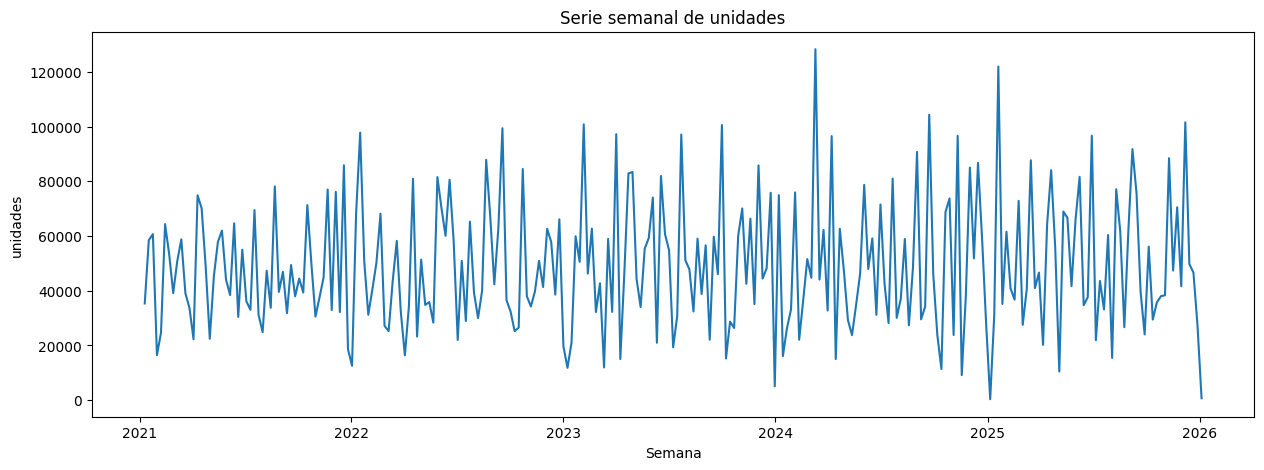

Rango temporal: 2021-01-10 00:00:00 -> 2026-01-04 00:00:00
Número de semanas: 261


,count,mean,std,min,25%,50%,75%,max
unidades,261.0,49098.394636,23363.029949,362.0,32258.0,44859.0,62935.0,128247.0


In [317]:
# VISUALIZACIÓN DE LA SERIE OBJETIVO (SEMANAL)

plt.figure(figsize=(15, 5))
plt.plot(serie_semanal[date_col], serie_semanal[TARGET_COL])
plt.title(f"Serie semanal de {TARGET_COL}")
plt.xlabel("Semana")
plt.ylabel(TARGET_COL)
plt.show()

print("Rango temporal:", serie_semanal[date_col].min(), "->", serie_semanal[date_col].max())
print("Número de semanas:", len(serie_semanal))
display(serie_semanal[[TARGET_COL]].describe().T)

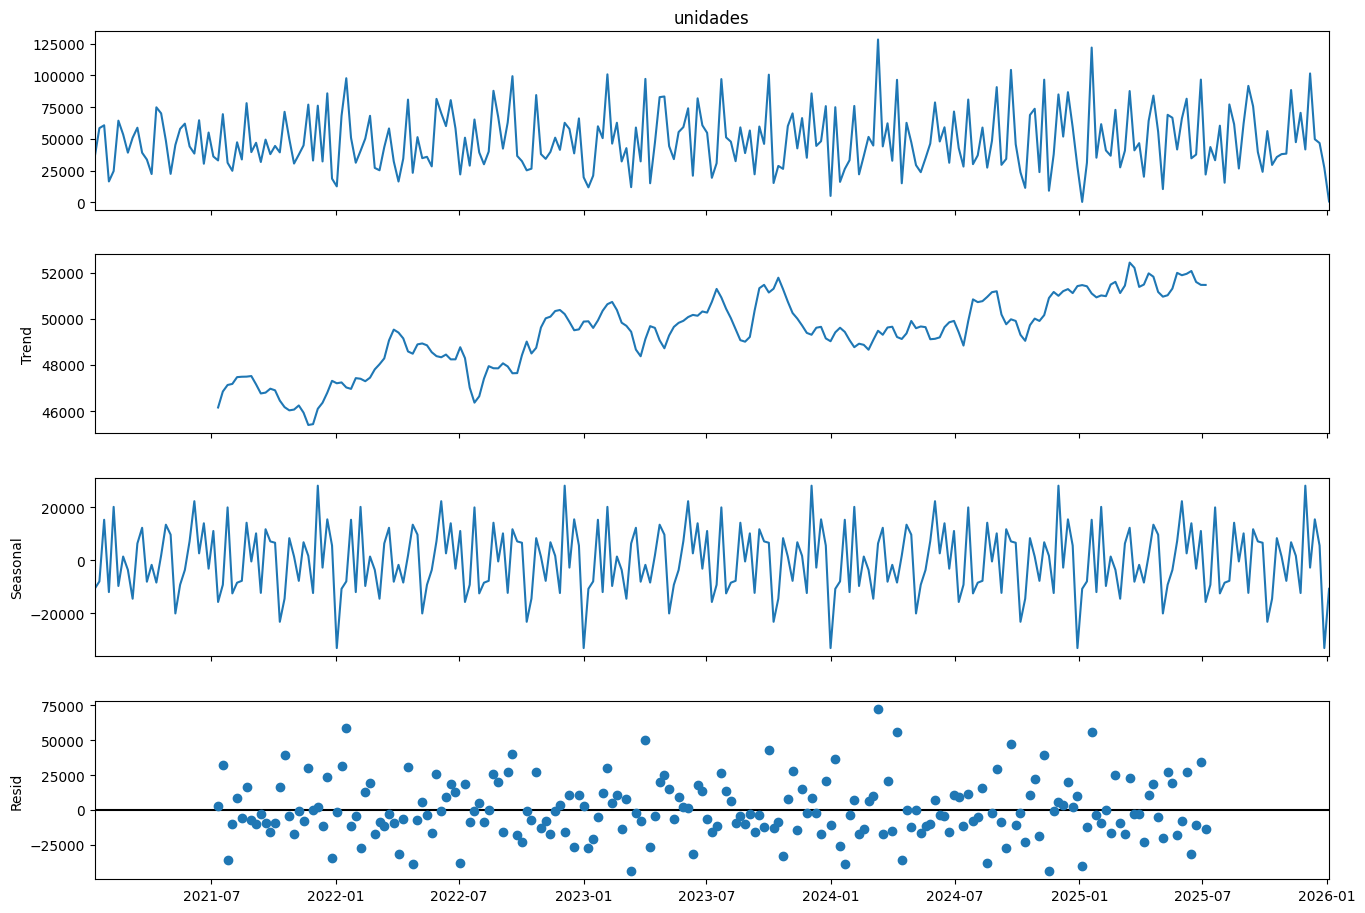

Niveles de serie semanal
ADF - unidades_weekly
  estadístico: -4.8505
  p-value    : 0.0000
  lags       : 12
  nobs       : 248
  valores críticos:
    1%: -3.4570
    5%: -2.8733
    10%: -2.5730
  conclusión : estacionaria

KPSS - unidades_weekly
  estadístico: 0.4523
  p-value    : 0.0546
  lags       : 24
  valores críticos:
    10%: 0.347
    5%: 0.463
    2.5%: 0.574
    1%: 0.739
  conclusión : no rechaza estacionariedad
Primera diferenciación de la serie semanal
ADF - unidades_weekly_diff1
  estadístico: -9.3447
  p-value    : 0.0000
  lags       : 13
  nobs       : 246
  valores críticos:
    1%: -3.4572
    5%: -2.8734
    10%: -2.5731
  conclusión : estacionaria

KPSS - unidades_weekly_diff1
  estadístico: 0.1580
  p-value    : 0.1000
  lags       : 32
  valores críticos:
    10%: 0.347
    5%: 0.463
    2.5%: 0.574
    1%: 0.739
  conclusión : no rechaza estacionariedad


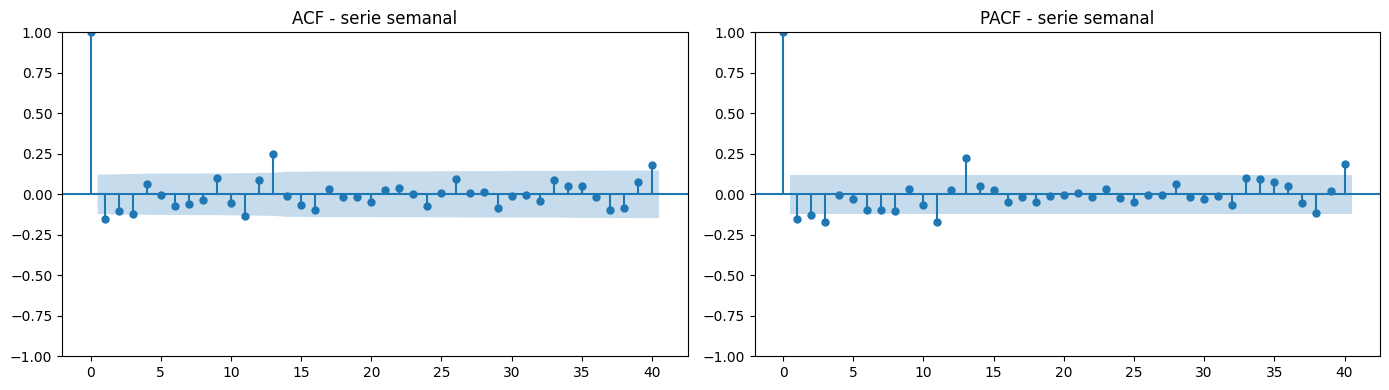

In [318]:
# DESCOMPOSICIÓN Y PRUEBAS DE ESTACIONARIEDAD

series = serie_semanal.set_index(date_col)[TARGET_COL].asfreq(DATA_FREQ)

# rellenar posibles huecos semanales
series = series.fillna(0)

decomp = seasonal_decompose(series, model="additive", period=SEASONAL_PERIOD)
fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.show()

print("Niveles de serie semanal")
run_adf(series, name=f"{TARGET_COL}_weekly")
print()
run_kpss(series, name=f"{TARGET_COL}_weekly")

series_diff = series.diff().dropna()

print("Primera diferenciación de la serie semanal")
run_adf(series_diff, name=f"{TARGET_COL}_weekly_diff1")
print()
run_kpss(series_diff, name=f"{TARGET_COL}_weekly_diff1")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series, ax=axes[0], lags=min(40, len(series) - 1))
plot_pacf(series, ax=axes[1], lags=min(40, len(series) - 2), method="ywm")
axes[0].set_title("ACF - serie semanal")
axes[1].set_title("PACF - serie semanal")
plt.tight_layout()
plt.show()

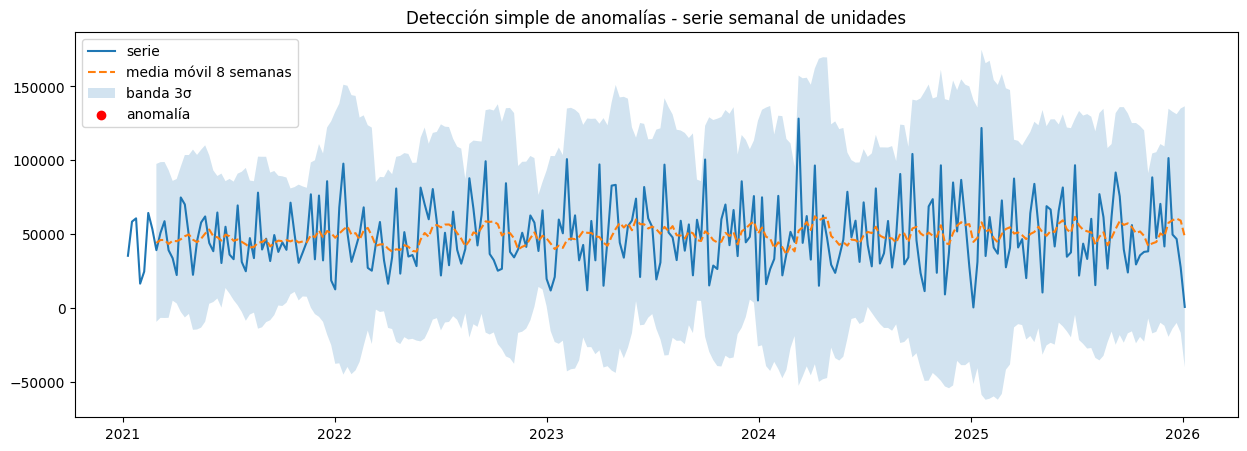

In [319]:
# DETECCIÓN SIMPLE DE ANOMALÍAS (SEMANAL)

tmp = serie_semanal[[date_col, TARGET_COL]].copy()
tmp[f"rolling_mean_{ANOMALY_WINDOW}"] = tmp[TARGET_COL].rolling(ANOMALY_WINDOW).mean()
tmp[f"rolling_std_{ANOMALY_WINDOW}"] = tmp[TARGET_COL].rolling(ANOMALY_WINDOW).std()
tmp["upper"] = tmp[f"rolling_mean_{ANOMALY_WINDOW}"] + 3 * tmp[f"rolling_std_{ANOMALY_WINDOW}"]
tmp["lower"] = tmp[f"rolling_mean_{ANOMALY_WINDOW}"] - 3 * tmp[f"rolling_std_{ANOMALY_WINDOW}"]
tmp["anomaly"] = np.where(
    (tmp[TARGET_COL] > tmp["upper"]) | (tmp[TARGET_COL] < tmp["lower"]),
    tmp[TARGET_COL],
    np.nan
)

plt.figure(figsize=(15, 5))
plt.plot(tmp[date_col], tmp[TARGET_COL], label="serie")
plt.plot(tmp[date_col], tmp[f"rolling_mean_{ANOMALY_WINDOW}"], "--", label=f"media móvil {ANOMALY_WINDOW} semanas")
plt.fill_between(tmp[date_col], tmp["lower"], tmp["upper"], alpha=0.2, label="banda 3σ")
plt.scatter(tmp[date_col], tmp["anomaly"], color="red", label="anomalía")
plt.legend()
plt.title(f"Detección simple de anomalías - serie semanal de {TARGET_COL}")
plt.show()

Train : (181, 23)
Valid : (40, 23)
Test  : (40, 23)


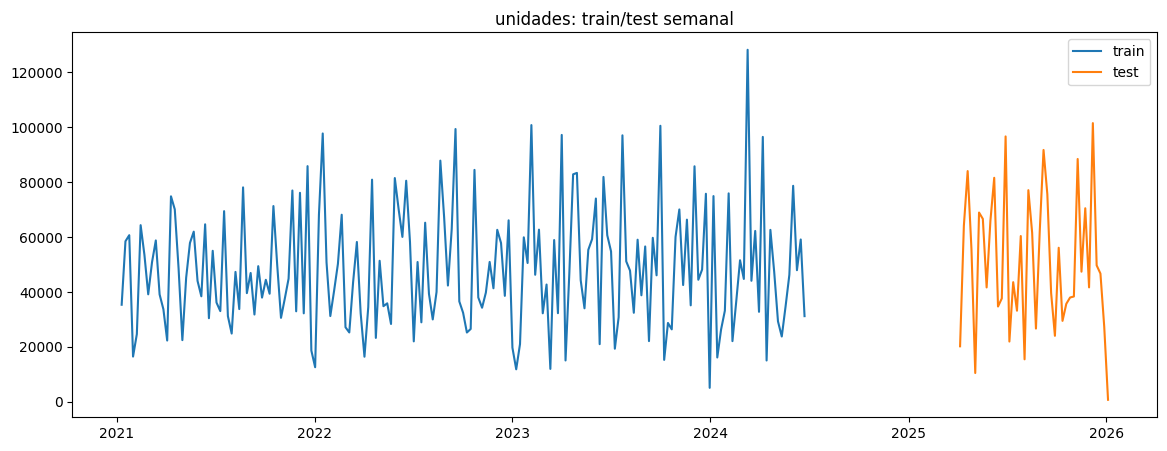

In [320]:
# TRAIN / VALID / TEST

serie_semanal = serie_semanal.sort_values(date_col).reset_index(drop=True)

train_valid = serie_semanal.iloc[:-TEST_SIZE].copy()
test = serie_semanal.iloc[-TEST_SIZE:].copy()

train = train_valid.iloc[:-VALID_SIZE].copy()
valid = train_valid.iloc[-VALID_SIZE:].copy()

print("Train :", train.shape)
print("Valid :", valid.shape)
print("Test  :", test.shape)

plot_train_test(
    train.set_index(date_col)[TARGET_COL],
    test.set_index(date_col)[TARGET_COL],
    f"{TARGET_COL}: train/test semanal"
)


In [321]:
# BASELINE: SEASONAL NAIVE

y_train = train.set_index(date_col)[TARGET_COL].asfreq(DATA_FREQ).fillna(0)
y_valid = valid.set_index(date_col)[TARGET_COL].asfreq(DATA_FREQ).fillna(0)

seasonal_naive_pred_valid = y_train.iloc[-SEASONAL_PERIOD:].iloc[:len(y_valid)].values

baseline_valid_scores = regression_metrics(
    y_valid,
    seasonal_naive_pred_valid,
    "Seasonal Naive"
)

display(baseline_valid_scores)

,modelo,MAE,RMSE,WAPE,MAPE,sMAPE,R2
0,Seasonal Naive,27310.35,35782.706639,53.818667,581.509266,56.453146,-0.677952


In [322]:
# SARIMA POR MEJOR WAPE - GRILLA INTERMEDIA CON PROGRESO

sarima_results = []

best_sarima_model = None
best_sarima_order = None
best_sarima_sorder = None
best_sarima_wape = np.inf

orders = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2)
]

sorders = [
    (0, 0, 0, SEASONAL_PERIOD),
    (1, 0, 0, SEASONAL_PERIOD),
    (0, 1, 1, SEASONAL_PERIOD),
    (1, 1, 1, SEASONAL_PERIOD),
    (2, 0, 0, SEASONAL_PERIOD),
    (0, 0, 1, SEASONAL_PERIOD)
]

total_modelos = len(orders) * len(sorders)
contador = 0

for order in orders:
    for sorder in sorders:
        contador += 1
        print(f"Probando modelo {contador}/{total_modelos}: order={order}, seasonal_order={sorder}")

        try:
            model = SARIMAX(
                y_train,
                order=order,
                seasonal_order=sorder,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            pred_valid = model.forecast(steps=len(y_valid))
            pred_valid = clip_nonnegative(pred_valid)

            score_wape = wape(y_valid, pred_valid)

            print(f"   WAPE valid: {score_wape:.2f}")

            sarima_results.append(
                regression_metrics(
                    y_valid,
                    pred_valid,
                    f"SARIMA_{order}_{sorder}"
                )
            )

            if score_wape < best_sarima_wape:
                best_sarima_wape = score_wape
                best_sarima_model = model
                best_sarima_order = order
                best_sarima_sorder = sorder
                print("   Nuevo mejor modelo")

        except Exception as e:
            print(f"   No corrió SARIMA {order} {sorder}: {e}")

sarima_valid_scores = (
    pd.concat(sarima_results, ignore_index=True)
    .sort_values(["WAPE", "RMSE"])
)

display(sarima_valid_scores.head(10))

print("Mejor SARIMA por WAPE:")
print("order:", best_sarima_order)
print("seasonal_order:", best_sarima_sorder)
print("WAPE valid:", best_sarima_wape)

Probando modelo 1/36: order=(0, 1, 1), seasonal_order=(0, 0, 0, 52)
   WAPE valid: 44.73
   Nuevo mejor modelo
Probando modelo 2/36: order=(0, 1, 1), seasonal_order=(1, 0, 0, 52)
   WAPE valid: 44.06
   Nuevo mejor modelo
Probando modelo 3/36: order=(0, 1, 1), seasonal_order=(0, 1, 1, 52)
   WAPE valid: 48.81
Probando modelo 4/36: order=(0, 1, 1), seasonal_order=(1, 1, 1, 52)
   WAPE valid: 50.13
Probando modelo 5/36: order=(0, 1, 1), seasonal_order=(2, 0, 0, 52)
   WAPE valid: 45.45
Probando modelo 6/36: order=(0, 1, 1), seasonal_order=(0, 0, 1, 52)
   WAPE valid: 58.66
Probando modelo 7/36: order=(1, 1, 0), seasonal_order=(0, 0, 0, 52)
   WAPE valid: 43.45
   Nuevo mejor modelo
Probando modelo 8/36: order=(1, 1, 0), seasonal_order=(1, 0, 0, 52)
   WAPE valid: 43.25
   Nuevo mejor modelo
Probando modelo 9/36: order=(1, 1, 0), seasonal_order=(0, 1, 1, 52)
   WAPE valid: 53.01
Probando modelo 10/36: order=(1, 1, 0), seasonal_order=(1, 1, 1, 52)
   WAPE valid: 52.53
Probando modelo 11/36

,modelo,MAE,RMSE,WAPE,MAPE,sMAPE,R2
7,"SARIMA_(1, 1, 0)_(1, 0, 0, 52)",21949.230259,29395.524349,43.253870,332.264964,46.511850,-0.132389
6,"SARIMA_(1, 1, 0)_(0, 0, 0, 52)",22048.132342,29196.156888,43.448769,328.752826,46.804867,-0.117081
11,"SARIMA_(1, 1, 0)_(0, 0, 1, 52)",22049.604740,29271.517209,43.451671,326.888698,46.812465,-0.122855
25,"SARIMA_(1, 1, 2)_(1, 0, 0, 52)",22312.061797,27591.870360,43.968877,403.831534,46.805922,0.002310
31,"SARIMA_(2, 1, 2)_(1, 0, 0, 52)",22321.357005,27605.538890,43.987195,402.605094,46.834692,0.001322
13,"SARIMA_(1, 1, 1)_(1, 0, 0, 52)",22350.047055,27553.064714,44.043732,400.536732,46.938338,0.005115
19,"SARIMA_(2, 1, 1)_(1, 0, 0, 52)",22356.726305,27563.498205,44.056895,398.718043,46.968783,0.004361
1,"SARIMA_(0, 1, 1)_(1, 0, 0, 52)",22359.637048,27581.772134,44.062631,404.468385,46.911045,0.003040
24,"SARIMA_(1, 1, 2)_(0, 0, 0, 52)",22605.998932,27672.548073,44.548120,393.907181,47.492210,-0.003533
30,"SARIMA_(2, 1, 2)_(0, 0, 0, 52)",22613.627049,27680.890276,44.563152,394.113979,47.502356,-0.004138


Mejor SARIMA por WAPE:
order: (1, 1, 0)
seasonal_order: (1, 0, 0, 52)
WAPE valid: 43.25386972528126


In [323]:
# SARIMAX CON EXÓGENAS

candidate_exog = [c for c in [
    "precio_neto", "porcentaje_descuento", "dcto",
    "dum_bonificacion", "dum_dscto_promo", "dum_dscto_tabla",
    "month", "quarter", "weekofyear"
] if c in train.columns]

sarimax_results = []

best_sarimax_model = None
best_sarimax_order = None
best_sarimax_sorder = None
best_sarimax_wape = np.inf

if len(candidate_exog) > 0:

    X_train_exog = train.set_index(date_col)[candidate_exog].asfreq(DATA_FREQ).ffill().bfill().fillna(0)
    X_valid_exog = valid.set_index(date_col)[candidate_exog].asfreq(DATA_FREQ).ffill().bfill().fillna(0)

    orders = [
        (0, 1, 1),
        (1, 1, 0),
        (1, 1, 1),
        (2, 1, 1),
        (1, 1, 2),
        (2, 1, 2)
    ]

    sorders = [
        (0, 0, 0, SEASONAL_PERIOD),
        (1, 0, 0, SEASONAL_PERIOD),
        (0, 1, 1, SEASONAL_PERIOD),
        (1, 1, 1, SEASONAL_PERIOD),
        (2, 0, 0, SEASONAL_PERIOD),
        (0, 0, 1, SEASONAL_PERIOD)
    ]

    total_modelos = len(orders) * len(sorders)  # 36
    contador = 0

    for order in orders:
        for sorder in sorders:
            contador += 1
            print(f"Probando SARIMAX {contador}/{total_modelos}: order={order}, seasonal_order={sorder}")

            try:
                model = SARIMAX(
                    y_train,
                    exog=X_train_exog,
                    order=order,
                    seasonal_order=sorder,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False)

                pred_valid = model.forecast(
                    steps=len(y_valid),
                    exog=X_valid_exog
                )

                pred_valid = clip_nonnegative(pred_valid)

                score_wape = wape(y_valid, pred_valid)
                print(f"   WAPE valid: {score_wape:.2f}")

                sarimax_results.append(
                    regression_metrics(
                        y_valid,
                        pred_valid,
                        f"SARIMAX_{order}_{sorder}"
                    )
                )

                if score_wape < best_sarimax_wape:
                    best_sarimax_wape = score_wape
                    best_sarimax_model = model
                    best_sarimax_order = order
                    best_sarimax_sorder = sorder
                    print("   Nuevo mejor modelo")

            except Exception as e:
                print(f"   No corrió SARIMAX {order} {sorder}: {e}")

    sarimax_valid_scores = (
        pd.concat(sarimax_results, ignore_index=True)
        .sort_values(["WAPE", "RMSE"])
    )

    display(sarimax_valid_scores.head(10))

    print("Mejor SARIMAX por WAPE:")
    print("order:", best_sarimax_order)
    print("seasonal_order:", best_sarimax_sorder)
    print("WAPE valid:", best_sarimax_wape)
    print("Variables exógenas usadas:", candidate_exog)


Probando SARIMAX 1/36: order=(0, 1, 1), seasonal_order=(0, 0, 0, 52)
   WAPE valid: 11.73
   Nuevo mejor modelo
Probando SARIMAX 2/36: order=(0, 1, 1), seasonal_order=(1, 0, 0, 52)
   WAPE valid: 12.47
Probando SARIMAX 3/36: order=(0, 1, 1), seasonal_order=(0, 1, 1, 52)
   WAPE valid: 18.61
Probando SARIMAX 4/36: order=(0, 1, 1), seasonal_order=(1, 1, 1, 52)
   WAPE valid: 18.75
Probando SARIMAX 5/36: order=(0, 1, 1), seasonal_order=(2, 0, 0, 52)
   WAPE valid: 13.02
Probando SARIMAX 6/36: order=(0, 1, 1), seasonal_order=(0, 0, 1, 52)
   WAPE valid: 556.82
Probando SARIMAX 7/36: order=(1, 1, 0), seasonal_order=(0, 0, 0, 52)
   WAPE valid: 14.61
Probando SARIMAX 8/36: order=(1, 1, 0), seasonal_order=(1, 0, 0, 52)
   WAPE valid: 15.94
Probando SARIMAX 9/36: order=(1, 1, 0), seasonal_order=(0, 1, 1, 52)
   WAPE valid: 30.12
Probando SARIMAX 10/36: order=(1, 1, 0), seasonal_order=(1, 1, 1, 52)
   WAPE valid: 36.93
Probando SARIMAX 11/36: order=(1, 1, 0), seasonal_order=(2, 0, 0, 52)
   WAP

,modelo,MAE,RMSE,WAPE,MAPE,sMAPE,R2
30,"SARIMAX_(2, 1, 2)_(0, 0, 0, 52)",5892.248733,7352.127030,11.611458,104.865322,17.220646,0.929163
18,"SARIMAX_(2, 1, 1)_(0, 0, 0, 52)",5924.336279,7378.937377,11.674690,104.645423,17.260902,0.928646
24,"SARIMAX_(1, 1, 2)_(0, 0, 0, 52)",5931.467519,7379.949591,11.688744,105.048798,17.288102,0.928626
12,"SARIMAX_(1, 1, 1)_(0, 0, 0, 52)",5947.986080,7398.424995,11.721296,105.094141,17.312866,0.928268
0,"SARIMAX_(0, 1, 1)_(0, 0, 0, 52)",5951.917114,7403.717167,11.729042,105.553398,17.335521,0.928166
31,"SARIMAX_(2, 1, 2)_(1, 0, 0, 52)",6128.633006,7650.723156,12.077284,97.663004,17.135683,0.923292
25,"SARIMAX_(1, 1, 2)_(1, 0, 0, 52)",6156.247454,7688.401315,12.131702,97.355582,17.169817,0.922535
19,"SARIMAX_(2, 1, 1)_(1, 0, 0, 52)",6174.760108,7642.870173,12.168184,93.047352,17.226629,0.923450
13,"SARIMAX_(1, 1, 1)_(1, 0, 0, 52)",6237.755625,7680.393274,12.292325,96.566666,17.451174,0.922696
1,"SARIMAX_(0, 1, 1)_(1, 0, 0, 52)",6328.825084,7760.038127,12.471789,93.100947,17.517423,0.921085


Mejor SARIMAX por WAPE:
order: (2, 1, 2)
seasonal_order: (0, 0, 0, 52)
WAPE valid: 11.61145771718239
Variables exógenas usadas: ['precio_neto', 'porcentaje_descuento', 'dcto', 'dum_bonificacion', 'dum_dscto_promo', 'dum_dscto_tabla', 'month', 'quarter', 'weekofyear']


In [324]:
# DATOS SUPERVISADOS PARA REGRESIÓN / ML

supervised = daily.copy()
supervised = make_lag_features(
    supervised,
    target_col=TARGET_COL,
    lags=LAG_STEPS,
    windows=ROLLING_WINDOWS
)

# lags para variables exógenas clave
for c in ["precio_neto", "porcentaje_descuento", "dcto"]:
    if c in supervised.columns:
        for lag in EXOG_LAGS:
            supervised[f"{c}_lag_{lag}"] = supervised[c].shift(lag)
        supervised[f"{c}_rollmean_{EXOG_ROLLING_WINDOW}"] = (
            supervised[c].shift(1).rolling(EXOG_ROLLING_WINDOW).mean()
        )

supervised = supervised.dropna().reset_index(drop=True)

supervised_train = supervised[supervised[date_col] < test[date_col].min()].copy()
supervised_test = supervised[supervised[date_col] >= test[date_col].min()].copy()

# dentro de train_valid hacemos una separación para CV temporal
target = TARGET_COL
drop_for_X = [target, date_col]
feature_cols = [c for c in supervised_train.columns if c not in drop_for_X]

X_train_ml = supervised_train[feature_cols].copy()
y_train_ml = supervised_train[target].copy()

X_test_ml = supervised_test[feature_cols].copy()
y_test_ml = supervised_test[target].copy()

numeric_features = choose_numeric_features(X_train_ml, exclude_cols=[])

preprocess_num = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[("num", preprocess_num, numeric_features)],
    remainder="drop"
)

print("Número de features:", len(feature_cols))
print("Shape train ML:", X_train_ml.shape)
print("Shape test ML :", X_test_ml.shape)

Número de features: 49
Shape train ML: (209, 49)
Shape test ML : (40, 49)


In [325]:
# MODELOS DE REGRESIÓN / ML

ml_results = []
ml_fitted_objects = {}

models_to_run = {
    "LinearRegression": (
        Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
        {}
    ),
    "Ridge": (
        Pipeline([("prep", preprocessor), ("model", Ridge())]),
        {"model__alpha": [0.1, 1.0, 5.0, 10.0, 20.0]}
    ),
    "ElasticNet": (
        Pipeline([("prep", preprocessor), ("model", ElasticNet(max_iter=5000))]),
        {"model__alpha": [0.0005, 0.001, 0.01, 0.1],
         "model__l1_ratio": [0.2, 0.5, 0.8]}
    )
}

if HAS_XGB:
    models_to_run["XGBoost"] = (
        Pipeline([("prep", preprocessor),
                  ("model", XGBRegressor(
                      random_state=42,
                      n_estimators=400,
                      objective="reg:squarederror",
                      subsample=0.9,
                      colsample_bytree=0.9
                  ))]),
        {"model__max_depth": [3, 5, 7],
         "model__learning_rate": [0.03, 0.05, 0.1]}
    )

for name, (pipe, grid) in models_to_run.items():
    print(f"Entrenando {name}...")
    if len(grid) == 0:
        fitted = clone(pipe).fit(X_train_ml, y_train_ml)
    else:
        gs = gridsearch_ts_model(pipe, grid, X_train_ml, y_train_ml, n_splits=5, scoring=WAPE_SCORER)
        fitted = gs.best_estimator_
        print("  mejores parámetros:", gs.best_params_)

    pred = fitted.predict(X_test_ml)
    pred = clip_nonnegative(pred)

    ml_results.append(regression_metrics(y_test_ml, pred, name))
    ml_fitted_objects[name] = {
        "model": fitted,
        "pred_test": pred
    }

ml_scores = pd.concat(ml_results, ignore_index=True).sort_values(["WAPE", "RMSE"])
display(ml_scores)


Entrenando LinearRegression...
Entrenando Ridge...
  mejores parámetros: {'model__alpha': 20.0}
Entrenando ElasticNet...
  mejores parámetros: {'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Entrenando XGBoost...
  mejores parámetros: {'model__learning_rate': 0.03, 'model__max_depth': 3}


,modelo,MAE,RMSE,WAPE,MAPE,sMAPE,R2
1,Ridge,3978.993333,5302.059026,7.828861,28.473151,13.072283,0.953190
2,ElasticNet,3999.593714,5323.752427,7.869394,28.045836,13.087784,0.952806
0,LinearRegression,4899.688780,6341.902079,9.640374,23.852962,14.680447,0.933029
3,XGBoost,5125.238672,5974.041246,10.084154,31.511490,15.843117,0.940573


In [326]:
# MODELO DE ENSAMBLE }# MODELO COMBINADO: RIDGE + ELASTIC NET

if "Ridge" in ml_fitted_objects and "ElasticNet" in ml_fitted_objects:

    pred_ridge = ml_fitted_objects["Ridge"]["pred_test"]
    pred_elastic = ml_fitted_objects["ElasticNet"]["pred_test"]

    # Promedio simple
    pred_combo = (pred_ridge + pred_elastic) / 2
    pred_combo = clip_nonnegative(pred_combo)

    # Métricas
    combo_result = regression_metrics(
        y_test_ml,
        pred_combo,
        "Ridge_ElasticNet_Ensemble"
    )

    ml_results.append(combo_result)

# Actualizar tabla
ml_scores = pd.concat(ml_results, ignore_index=True).sort_values(["WAPE", "RMSE"])
display(ml_scores)

,modelo,MAE,RMSE,WAPE,MAPE,sMAPE,R2
1,Ridge,3978.993333,5302.059026,7.828861,28.473151,13.072283,0.953190
4,Ridge_ElasticNet_Ensemble,3988.033213,5312.027237,7.846648,28.257406,13.078095,0.953014
2,ElasticNet,3999.593714,5323.752427,7.869394,28.045836,13.087784,0.952806
0,LinearRegression,4899.688780,6341.902079,9.640374,23.852962,14.680447,0.933029
3,XGBoost,5125.238672,5974.041246,10.084154,31.511490,15.843117,0.940573


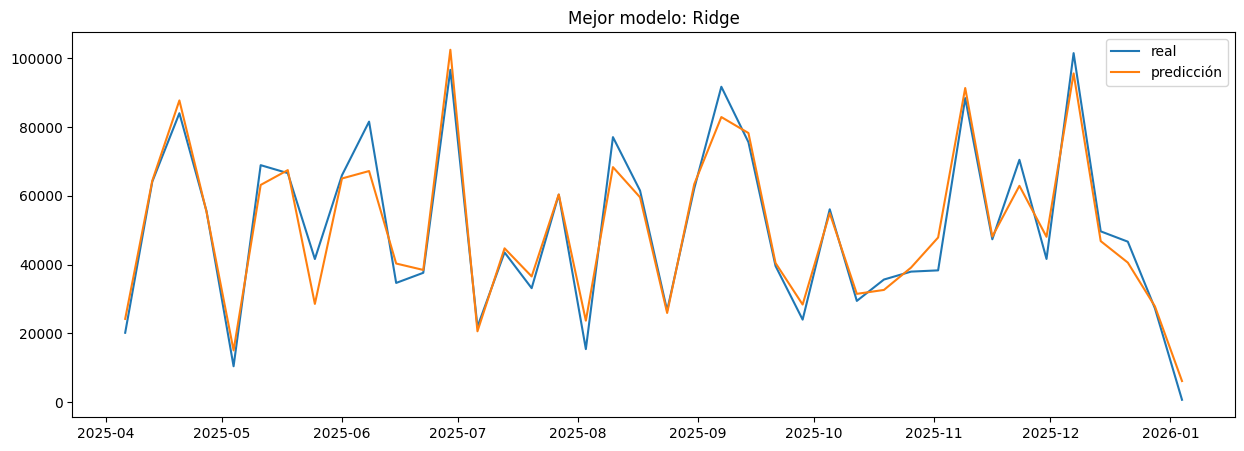

In [327]:
# GRÁFICO REAL VS PREDICHO DEL MEJOR MODELO

best_model_name = 'Ridge'
best_predictions = pd.Series(ml_fitted_objects[best_model_name]["pred_test"], index=supervised_test[date_col])

plt.figure(figsize=(15, 5))
if best_model_name in ml_fitted_objects:
    plt.plot(supervised_test[date_col], y_test_ml.values, label="real")
    plt.plot(supervised_test[date_col], best_predictions.values, label="predicción")
else:
    plt.plot(y_test.index, y_test.values, label="real")
    plt.plot(best_predictions.index, best_predictions.values, label="predicción")

plt.title(f"Mejor modelo: {best_model_name}")
plt.legend()
plt.show()


,modelo,LjungBox_p_10,JarqueBera_p,DurbinWatson,skew,kurtosis
0,Ridge,0.01637,0.124786,2.333322,0.764262,3.401255


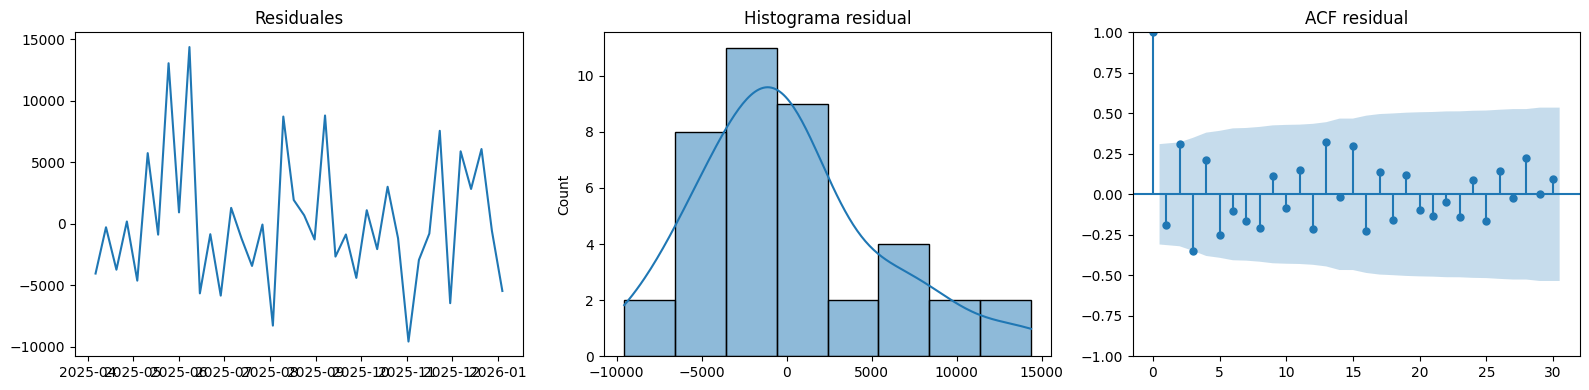

In [328]:
# DIAGNÓSTICO RESIDUAL DEL MEJOR MODELO

if best_model_name in ml_fitted_objects:
    diag = add_residual_diagnostics(y_test_ml, best_predictions.values, best_model_name)
    resid = pd.Series(y_test_ml.values - best_predictions.values, index=supervised_test[date_col])
else:
    diag = add_residual_diagnostics(y_test, best_predictions.values, best_model_name)
    resid = pd.Series(y_test.values - best_predictions.values, index=best_predictions.index)

display(diag)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(resid.index, resid.values)
axes[0].set_title("Residuales")
sns.histplot(resid, kde=True, ax=axes[1])
axes[1].set_title("Histograma residual")
plot_acf(resid.dropna(), ax=axes[2], lags=30)
axes[2].set_title("ACF residual")
plt.tight_layout()
plt.show()


In [329]:
# MODELO DE REGRESIÓN ECONOMÉTRICA (ELASTICIDAD)

# Versión semanal agregada: log(unidades) ~ log(precio_neto) + descuento + calendario + rezagos

econ = serie_semanal.copy()

required_cols = [TARGET_COL]
if "precio_neto" not in econ.columns:
    raise ValueError("Para la elasticidad necesito la columna 'precio_neto' en la agregación semanal.")

econ = make_time_features(econ, date_col=date_col)
econ["log_y"] = np.log1p(econ[TARGET_COL].clip(lower=0))
econ["log_precio_neto"] = np.log1p(econ["precio_neto"].clip(lower=0))

# rezagos semanales del target
for lag in [1, 2, 4]:
    econ[f"{TARGET_COL}_lag_{lag}"] = econ[TARGET_COL].shift(lag)

econ = econ.dropna().copy()

# dummies de calendario para datos semanales
month_dummies = pd.get_dummies(econ["month"], prefix="m", drop_first=True).astype(int)

X_econ = pd.concat([
    econ[["log_precio_neto"] +
         [c for c in ["porcentaje_descuento",
                      f"{TARGET_COL}_lag_1", f"{TARGET_COL}_lag_2", f"{TARGET_COL}_lag_4"] if c in econ.columns]],
    month_dummies
], axis=1)

X_econ = sm.add_constant(X_econ)
y_econ = econ["log_y"]

ols_model = sm.OLS(y_econ, X_econ).fit(cov_type="HC3")
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  log_y   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     2.631
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           0.000808
Time:                        00:59:53   Log-Likelihood:                -228.02
No. Observations:                 257   AIC:                             490.0
Df Residuals:                     240   BIC:                             550.4
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    8.2912 

In [330]:
# =========================
# 23. PRUEBAS PARA EL MODELO ECONOMÉTRICO
# =========================
# VIF (colinealidad)
vif_df = pd.DataFrame({
    "variable": X_econ.columns,
    "VIF": [variance_inflation_factor(X_econ.values, i) for i in range(X_econ.shape[1])]
})
display(vif_df.sort_values("VIF", ascending=False).head(20))

# Breusch-Pagan (heterocedasticidad)
bp_test = het_breuschpagan(ols_model.resid, ols_model.model.exog)
bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print("Breusch-Pagan:")
for label, val in zip(bp_labels, bp_test):
    print(f"  {label}: {val}")

print("\nDurbin-Watson:", durbin_watson(ols_model.resid))
jb = jarque_bera(ols_model.resid)
print("Jarque-Bera p-value:", jb[1])


,variable,VIF
0,const,377.757217
16,m_12,2.099845
10,m_6,2.088610
13,m_9,2.085478
14,m_10,2.074412
12,m_8,2.060557
11,m_7,2.058410
9,m_5,2.016153
7,m_3,2.010268
15,m_11,1.997892


Breusch-Pagan:
  LM stat: 44.107618930327256
  LM p-value: 0.00018995816127075096
  F stat: 3.1077405430417175
  F p-value: 8.207688703481258e-05

Durbin-Watson: 1.7895427465908156
Jarque-Bera p-value: 0.0


In [331]:
# PRUEBAS PARA EL MODELO ECONOMÉTRICO

# VIF (colinealidad)
vif_df = pd.DataFrame({
    "variable": X_econ.columns,
    "VIF": [variance_inflation_factor(X_econ.values, i) for i in range(X_econ.shape[1])]
})
display(vif_df.sort_values("VIF", ascending=False).head(20))

# Breusch-Pagan (heterocedasticidad)
bp_test = het_breuschpagan(ols_model.resid, ols_model.model.exog)
bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print("Breusch-Pagan:")
for label, val in zip(bp_labels, bp_test):
    print(f"  {label}: {val}")

print("\nDurbin-Watson:", durbin_watson(ols_model.resid))
jb = jarque_bera(ols_model.resid)
print("Jarque-Bera p-value:", jb[1])


,variable,VIF
0,const,377.757217
16,m_12,2.099845
10,m_6,2.088610
13,m_9,2.085478
14,m_10,2.074412
12,m_8,2.060557
11,m_7,2.058410
9,m_5,2.016153
7,m_3,2.010268
15,m_11,1.997892


Breusch-Pagan:
  LM stat: 44.107618930327256
  LM p-value: 0.00018995816127075096
  F stat: 3.1077405430417175
  F p-value: 8.207688703481258e-05

Durbin-Watson: 1.7895427465908156
Jarque-Bera p-value: 0.0


Elasticidad Precio por Producto y Categoría (primeras 20 filas):


,producto,categoria,n,elasticidad_precio,p_value,r2
17,DERMA 1,Cadena Pequeña,2362,-5.300859,0.000000e+00,0.484438
38,RESPIRATORIO 1,Cadena Pequeña,7344,-4.011807,2.612802e-80,0.043026
1,CARDIO 1,Cadena Mediana,1188,6.425714,2.402714e-66,0.082299
3,CARDIO 2,Cadena Grande,490,-49.033349,5.304799e-45,0.232133
46,SNC2,Cadena Mediana,1600,4.557136,2.874535e-33,0.056598
37,RESPIRATORIO 1,Cadena Mediana,1474,5.735567,1.047576e-19,0.058335
14,CONSUMO 3,Cadena Pequeña,18225,-0.510440,1.766325e-19,0.003684
23,ENDO 1,Cadena Pequeña,1587,-0.582964,9.176790e-18,0.035612
15,DERMA 1,Cadena Grande,492,-27.311912,1.314998e-17,0.157826
43,SNC1,Cadena Mediana,1122,3.886315,1.622094e-17,0.036836


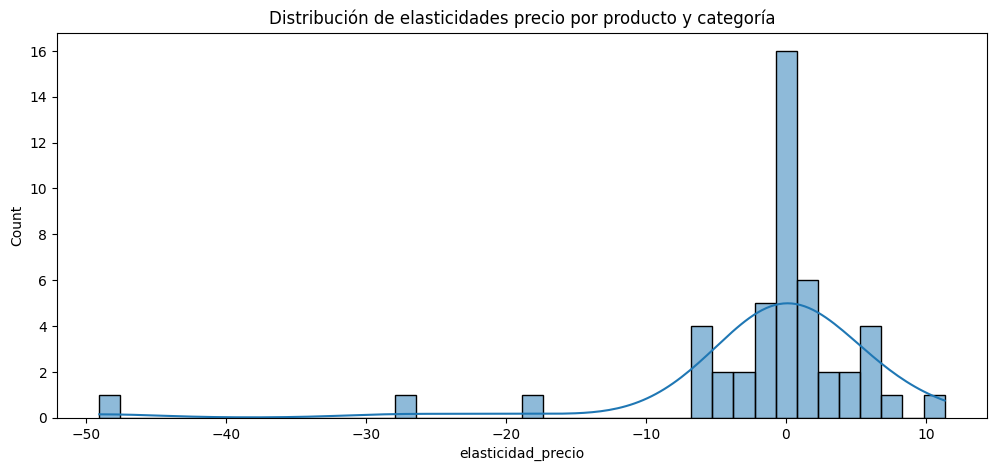

In [332]:
product_col = 'nombre_anonimizado'
category_col = 'categoria_'

if product_col is not None and category_col is not None and "precio_neto" in df.columns and "unidades" in df.columns:
    elasticidades = []

    # Agrupar por producto y categoría
    for (prod, cat), g in df.groupby([product_col, category_col]):
        g = g[[date_col, "precio_neto", "unidades"]].dropna().copy()
        if len(g) < MIN_OBS_PRODUCT:
            continue

        g = g[g["precio_neto"] > 0]
        g = g[g["unidades"] >= 0]

        if len(g) < MIN_OBS_PRODUCT:
            continue

        g["log_q"] = np.log1p(g["unidades"])
        g["log_p"] = np.log1p(g["precio_neto"])

        Xp = sm.add_constant(g[["log_p"]])
        yp = g["log_q"]

        try:
            m = sm.OLS(yp, Xp).fit(cov_type="HC3")
            elasticidades.append({
                "producto": prod,
                "categoria": cat, # Añadir la categoría
                "n": len(g),
                "elasticidad_precio": m.params["log_p"],
                "p_value": m.pvalues["log_p"],
                "r2": m.rsquared
            })
        except Exception:
            pass

    elasticidades_df = pd.DataFrame(elasticidades).sort_values(["p_value", "elasticidad_precio"])
    print("Elasticidad Precio por Producto y Categoría (primeras 20 filas):")
    display(elasticidades_df.head(20))

    plt.figure(figsize=(12, 5))
    sns.histplot(elasticidades_df["elasticidad_precio"], bins=40, kde=True)
    plt.title("Distribución de elasticidades precio por producto y categoría")
    plt.show()
else:
    print("No se pudo correr la elasticidad por producto y categoría porque falta nombre_anonimizado, categoria, o columnas clave.")

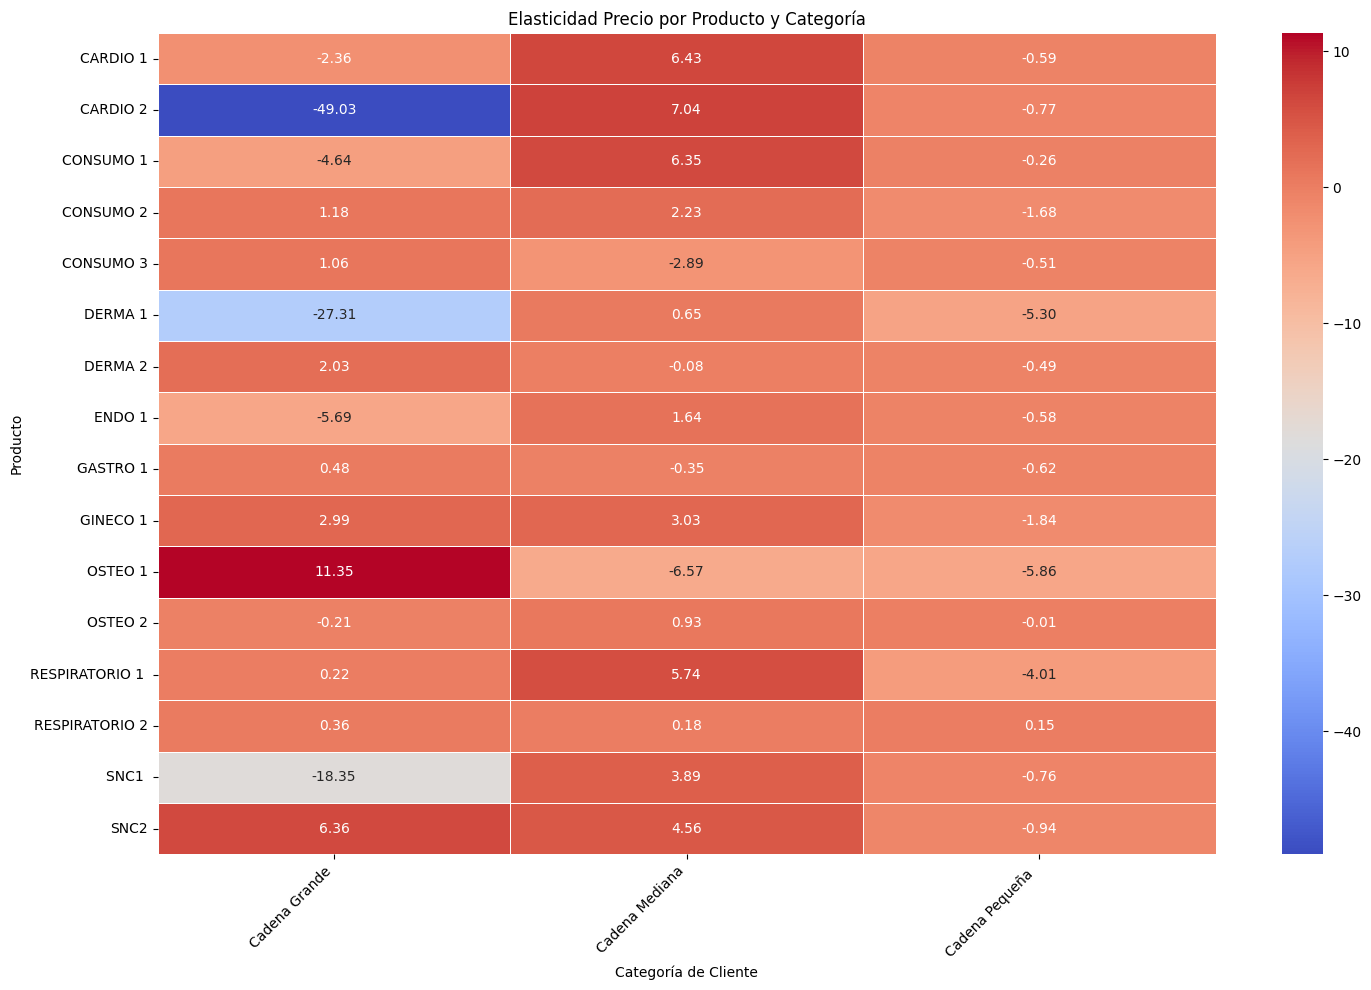

In [333]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una tabla pivote para el mapa de calor
pivot_elasticidad = elasticidades_df.pivot_table(
    index='producto',
    columns='categoria',
    values='elasticidad_precio'
)

plt.figure(figsize=(15, 10))
sns.heatmap(
    pivot_elasticidad,
    annot=True, # Mostrar los valores de elasticidad en el mapa de calor
    cmap='coolwarm', # Elegir un mapa de color divergente para elasticidades (positivas/negativas)
    fmt=".2f", # Formatear los números a dos decimales
    linewidths=.5 # Añadir líneas entre las celdas
)
plt.title('Elasticidad Precio por Producto y Categoría')
plt.xlabel('Categoría de Cliente')
plt.ylabel('Producto')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [334]:
# DATAFRAME SEMANAL PARA PROPHET

df_prophet_agg = daily[[DATE_COL, TARGET_COL, "precio_neto"]].copy()

df_prophet_agg = df_prophet_agg.rename(columns={
    DATE_COL: "ds",
    TARGET_COL: "y"
})

df_prophet_agg["ds"] = pd.to_datetime(df_prophet_agg["ds"])
df_prophet_agg["y"] = pd.to_numeric(df_prophet_agg["y"], errors="coerce")
df_prophet_agg["precio_neto"] = pd.to_numeric(df_prophet_agg["precio_neto"], errors="coerce")

df_prophet_agg = df_prophet_agg.sort_values("ds").dropna(subset=["ds", "y"]).reset_index(drop=True)

print("Shape:", df_prophet_agg.shape)
print("Filas con y no nulo:", df_prophet_agg["y"].notna().sum())
display(df_prophet_agg.head())
display(df_prophet_agg.tail())

Shape: (261, 3)
Filas con y no nulo: 261


,ds,y,precio_neto
0,2021-01-10,35346.0,5.208055
1,2021-01-17,58480.0,5.065228
2,2021-01-24,60693.0,4.634073
3,2021-01-31,16463.0,4.645514
4,2021-02-07,24649.0,5.115476


,ds,y,precio_neto
256,2025-12-07,101524.0,6.193769
257,2025-12-14,49700.0,5.754793
258,2025-12-21,46699.0,4.736232
259,2025-12-28,27326.0,5.981634
260,2026-01-04,720.0,5.132695


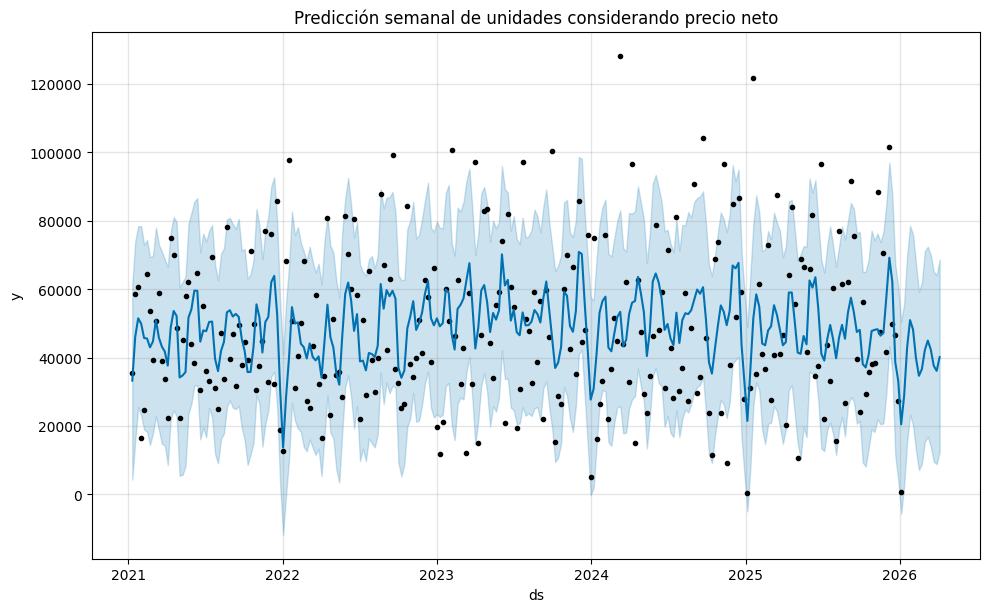

     regressor regressor_mode    center   coef_lower         coef   coef_upper
0  precio_neto       additive  5.598025  8555.966062  8555.966062  8555.966062


In [335]:
from prophet import Prophet
from prophet.utilities import regressor_coefficients

# MODELO PROPHET SEMANAL
m = Prophet(
    holidays=None,
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=True
)

# añadir regressor
m.add_regressor("precio_neto")

# entrenar
m.fit(df_prophet_agg)

# crear 13 semanas futuras
future = m.make_future_dataframe(periods=13, freq="W")

# completar precio_neto para el futuro con el último valor observado
ultimo_precio = df_prophet_agg["precio_neto"].iloc[-1]
future["precio_neto"] = df_prophet_agg["precio_neto"].tolist() + [ultimo_precio] * 13

# predecir
forecast = m.predict(future)

# visualizar
fig = m.plot(forecast)
plt.title("Predicción semanal de unidades considerando precio neto")
plt.show()

print(regressor_coefficients(m))

In [336]:
import pandas as pd
import unicodedata
import re

def clean_col_name(col_name):
    cleaned_name = col_name.lower()
    cleaned_name = cleaned_name.replace(' ', '_')
    cleaned_name = unicodedata.normalize('NFKD', cleaned_name).encode('ascii', 'ignore').decode('utf-8')
    cleaned_name = re.sub(r'[^a-z0-9_]', '', cleaned_name)
    return cleaned_name

new_columns = [clean_col_name(col) for col in df.columns]
df.columns = new_columns

df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y', errors='coerce')
df['vencimiento'] = pd.to_datetime(df['vencimiento'], format='%d/%m/%Y', errors='coerce')
df['costo_unitario'] = pd.to_numeric(df['costo_unitario'], errors='coerce')
df['costo_total'] = df['costo_unitario'] * df['unidades']
df['margen_bruto'] = df['valor_neto'] - df['costo_total']
median_costo_unitario = df['costo_unitario'].median()
df['costo_unitario'].fillna(median_costo_unitario, inplace=True)
# --- End of copied code ---

product_name = 'CARDIO 2'
filtered_products = df[df['nombre_anonimizado'] == product_name]['id_producto']

if not filtered_products.empty:
    respiratorio1_id_str = filtered_products.iloc[0]
    print(f"El id_producto para '{product_name}' es: {respiratorio1_id_str}")

    categoria = 'Cadena Grande'
    modelo_respiratorio1 = train_predictive_model(df, respiratorio1_id_str, categoria)

    if modelo_respiratorio1:
        print(modelo_respiratorio1.summary())
        # Extraer el coeficiente para 'porcentaje_descuento' si existe
        if 'porcentaje_descuento' in modelo_respiratorio1.params.index:
            discount_coef = modelo_respiratorio1.params['porcentaje_descuento']
            print(f"\nEl coeficiente para 'porcentaje_descuento' en este modelo es: {discount_coef:.4f}")
            print("Este coeficiente indica cómo, históricamente, el porcentaje de descuento ha influido en las unidades vendidas para 'RESPIRATORIO 1' en la categoría 'Cadena Mediana'.")
            print(f"Un valor de {discount_coef:.4f} significa que por cada aumento de 0.01 (un punto porcentual) en el porcentaje de descuento (dado que la variable está en formato decimal), las unidades vendidas han cambiado en aproximadamente {discount_coef * 0.01:.4f} unidades, ceteris paribus.")
            print(f"Para un escenario con un descuento del 25% (es decir, un valor de 0.25 para la variable 'porcentaje_descuento'), esto implicaría una contribución a las unidades de aproximadamente {discount_coef * 0.25:.4f}, además de los efectos de estacionalidad y tendencia capturados por el modelo.")
        else:
            print("\n'porcentaje_descuento' no es una variable en este modelo, o no fue incluida en las características durante el entrenamiento.")
    else:
        print(f"No se pudo entrenar el modelo para el producto {respiratorio1_id_str} en la categoría '{categoria}'.")

    print("\nSi deseas realizar una simulación de ventas con un descuento específico del 25% (o cualquier otro valor), necesitaríamos generar un conjunto de datos futuro con ese 'porcentaje_descuento' y utilizar el modelo entrenado para obtener una predicción específica de unidades.")
else:
    print(f"Error: No se encontró el producto '{product_name}' en la columna 'nombre_anonimizado'.")
    print("Valores únicos en 'nombre_anonimizado' para verificar:")
    print(df['nombre_anonimizado'].unique())

El id_producto para 'CARDIO 2' es: 10230422
                            OLS Regression Results                            
Dep. Variable:               unidades   R-squared:                       0.206
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     155.0
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.52e-89
Time:                        00:59:55   Log-Likelihood:                -14273.
No. Observations:                1795   AIC:                         2.855e+04
Df Residuals:                    1791   BIC:                         2.858e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

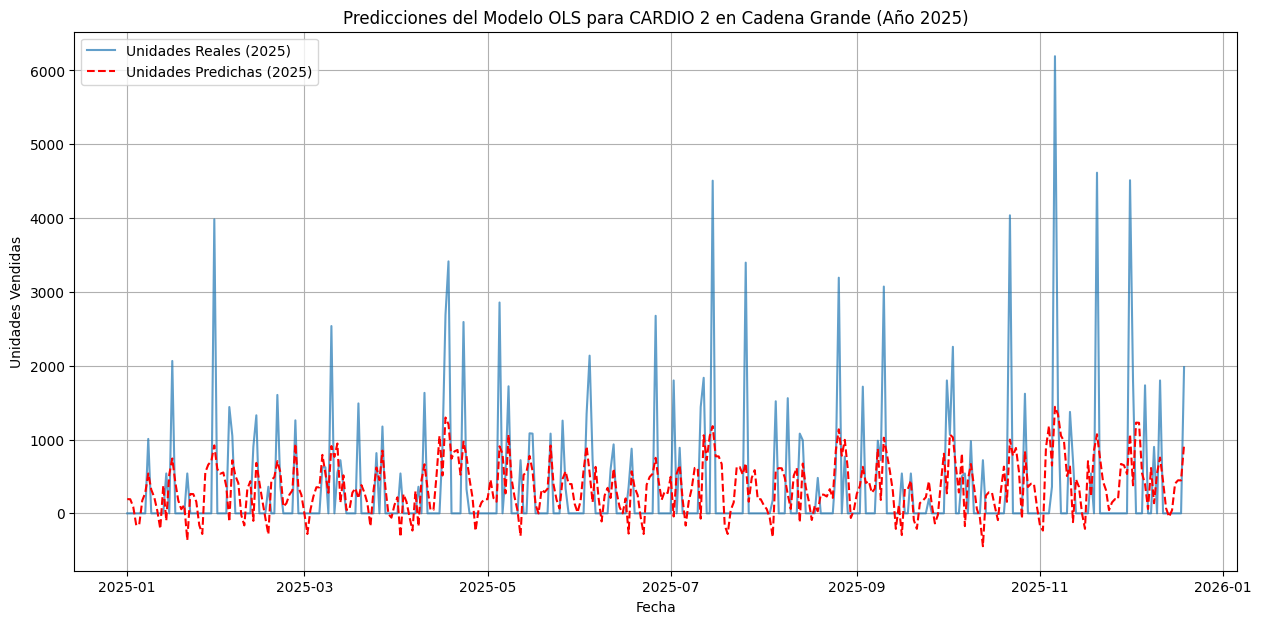

In [337]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Obtener los parámetros del modelo de la celda anterior
product_name = 'CARDIO 2'
respiratorio1_id_str = df[df['nombre_anonimizado'] == product_name]['id_producto'].iloc[0]
categoria = 'Cadena Grande'

# Re-preparar los datos como se hizo en train_predictive_model
subset = df[(df['id_producto'] == respiratorio1_id_str) & (df['categoria_'] == categoria)]

# Asegurarse de que date_col esté en formato datetime
subset['fecha'] = pd.to_datetime(subset['fecha'])

# Aplicar extract_time_features
# Nota: La función extract_time_features modificará el subset para la descomposición
# y puede llenar NaNs si hay días sin ventas.
processed_subset = extract_time_features(subset.copy()) # Usa una copia para no alterar el DataFrame original

# Verificar si processed_subset es válido y tiene suficientes datos
if processed_subset is None or processed_subset.empty or len(processed_subset) < 14:
    print(f"No hay suficientes datos válidos/suficientes para graficar el producto {respiratorio1_id_str} en la categoría '{categoria}'.")
else:
    # Definimos X (Variables independientes) y y (Variable dependiente)
    X_plot = processed_subset[['estacionalidad', 'tendencia', 'porcentaje_descuento']]
    X_plot = sm.add_constant(X_plot) # Para el intercepto Beta 0
    y_plot = processed_subset['unidades']

    # Re-entrenar el modelo para asegurar que tenemos el modelo y los datos X, y correspondientes
    # (esto es necesario si `train_predictive_model` solo retorna el modelo)
    try:
        modelo_actual = sm.OLS(y_plot, X_plot).fit()
        predictions = modelo_actual.predict(X_plot)

        # Filtrar datos para el año 2025
        filtered_2025 = processed_subset[processed_subset['fecha'].dt.year == 2025]
        predictions_2025 = predictions[filtered_2025.index]
        y_plot_2025 = y_plot[filtered_2025.index]

        plt.figure(figsize=(15, 7))
        plt.plot(filtered_2025['fecha'], y_plot_2025, label='Unidades Reales (2025)', alpha=0.7)
        plt.plot(filtered_2025['fecha'], predictions_2025, label='Unidades Predichas (2025)', linestyle='--', color='red')
        plt.title(f'Predicciones del Modelo OLS para {product_name} en {categoria} (Año 2025)')
        plt.xlabel('Fecha')
        plt.ylabel('Unidades Vendidas')
        plt.legend()
        plt.grid(True)
        plt.show()
    except Exception as e:
        print(f"Error al generar el gráfico: {e}")

In [338]:
future_2026 = pd.DataFrame({
    "fecha": pd.date_range("2026-01-01", "2026-12-31", freq="D")
})

ultima_tendencia = int(processed_subset["tendencia"].max())

future_2026["tendencia"] = range(
    ultima_tendencia + 1,
    ultima_tendencia + 1 + len(future_2026)
)

future_2026["estacionalidad"] = processed_subset["estacionalidad"].mean()
future_2026["porcentaje_descuento"] = processed_subset["porcentaje_descuento"].mean()

X_2026 = future_2026[["estacionalidad", "tendencia", "porcentaje_descuento"]]
X_2026 = sm.add_constant(X_2026, has_constant="add")

future_2026["unidades"] = modelo_actual.predict(X_2026).clip(lower=0)

predictions_df_2026 = future_2026[["fecha", "unidades"]]

display(predictions_df_2026.head())
display(predictions_df_2026.tail())

,fecha,unidades
0,2026-01-01,1443.073743
1,2026-01-02,1443.974815
2,2026-01-03,1444.875888
3,2026-01-04,1445.776960
4,2026-01-05,1446.678033


,fecha,unidades
360,2026-12-27,1767.459872
361,2026-12-28,1768.360945
362,2026-12-29,1769.262018
363,2026-12-30,1770.163090
364,2026-12-31,1771.064163


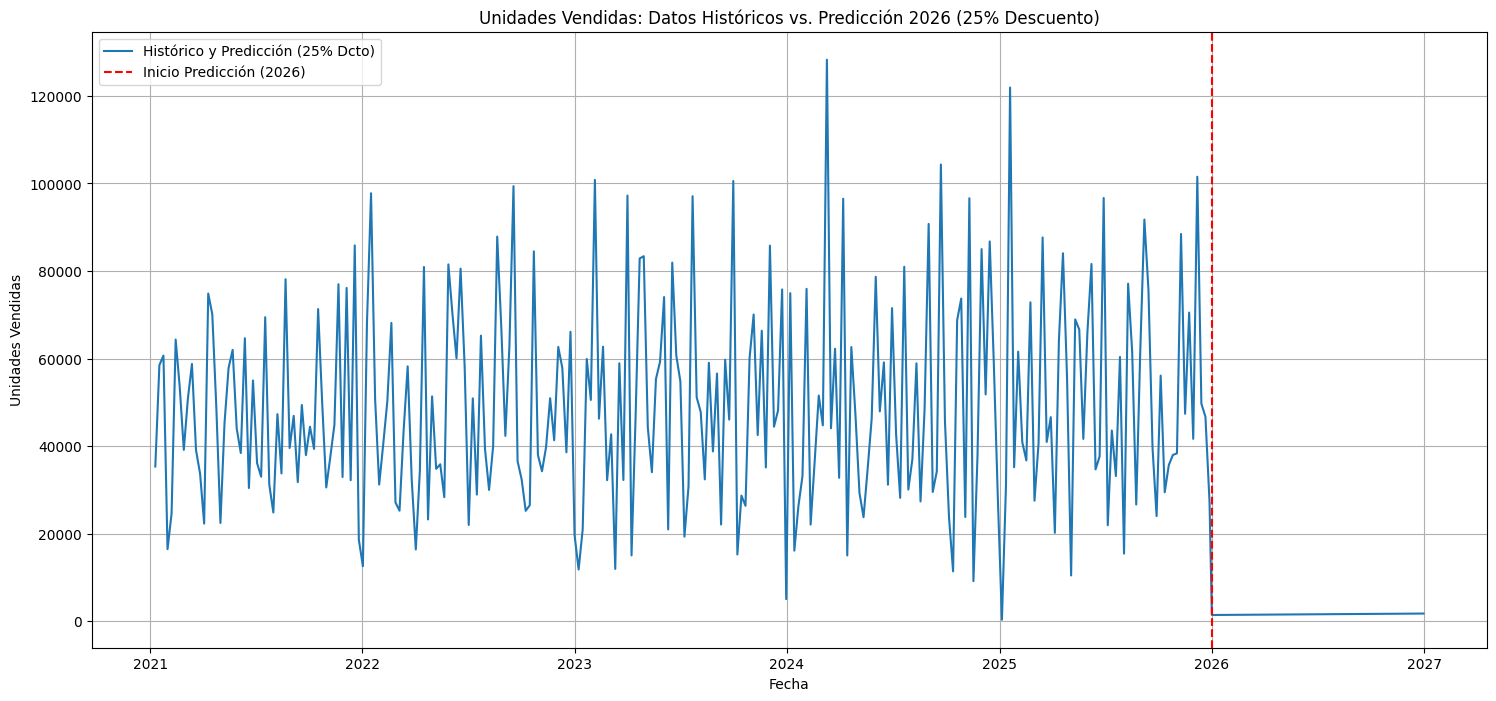

In [339]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un DataFrame para las predicciones de 2026 con su fecha
predictions_df_2026 = future_2026[['fecha', 'unidades']].copy()

# Filtrar los datos históricos hasta la última fecha antes de 2026
historical_data = daily[daily['fecha'] < predictions_df_2026['fecha'].min()].copy()

# Unir los datos históricos y las predicciones
full_sales_data = pd.concat([historical_data[['fecha', 'unidades']], predictions_df_2026], ignore_index=True)

plt.figure(figsize=(18, 8))
sns.lineplot(x='fecha', y='unidades', data=full_sales_data, label='Histórico y Predicción (25% Dcto)')

# Resaltar la sección de predicción
plt.axvline(x=predictions_df_2026['fecha'].min(), color='red', linestyle='--', label='Inicio Predicción (2026)')

plt.title('Unidades Vendidas: Datos Históricos vs. Predicción 2026 (25% Descuento)')
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.legend()
plt.grid(True)
plt.show()

# Regresión

In [340]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# CONFIGURACIÓN
product_name = 'CARDIO 2'
categoria = 'Cadena Grande'
scenario_discount = 0.25
future_periods = 52

# ASEGURAR TIPOS
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df['unidades'] = pd.to_numeric(df['unidades'], errors='coerce')
df['precio_neto'] = pd.to_numeric(df['precio_neto'], errors='coerce')
df['porcentaje_descuento'] = pd.to_numeric(df['porcentaje_descuento'], errors='coerce')

# FILTRAR PRODUCTO Y CATEGORÍA
subset = df[
    (df['nombre_anonimizado'] == product_name) &
    (df['categoria_'] == categoria)
].copy()

if subset.empty:
    raise ValueError(f"No hay datos para el producto '{product_name}' en la categoría '{categoria}'.")

# AGREGACIÓN SEMANAL
serie_weekly = (
    subset.assign(semana=subset['fecha'].dt.to_period('W-SUN').dt.end_time.dt.normalize())
          .groupby('semana')
          .agg({
              'unidades': 'sum',
              'precio_neto': 'mean',
              'porcentaje_descuento': 'mean'
          })
          .reset_index()
          .rename(columns={'semana': 'fecha'})
          .sort_values('fecha')
          .reset_index(drop=True)
)

# completar semanas faltantes
idx = pd.date_range(serie_weekly['fecha'].min(), serie_weekly['fecha'].max(), freq='W-SUN')
serie_weekly = (
    serie_weekly.set_index('fecha')
                .reindex(idx)
                .rename_axis('fecha')
                .reset_index()
)

serie_weekly['unidades'] = serie_weekly['unidades'].fillna(0)
serie_weekly['precio_neto'] = serie_weekly['precio_neto'].ffill().bfill()
serie_weekly['porcentaje_descuento'] = serie_weekly['porcentaje_descuento'].fillna(0)

# FEATURES PARA EL MODELO
serie_weekly['year'] = serie_weekly['fecha'].dt.year
serie_weekly['month'] = serie_weekly['fecha'].dt.month
serie_weekly['quarter'] = serie_weekly['fecha'].dt.quarter
serie_weekly['weekofyear'] = serie_weekly['fecha'].dt.isocalendar().week.astype(int)

for lag in [1, 2, 4, 8]:
    serie_weekly[f'lag_{lag}'] = serie_weekly['unidades'].shift(lag)

for w in [4, 8]:
    serie_weekly[f'rollmean_{w}'] = serie_weekly['unidades'].shift(1).rolling(w).mean()

for lag in [1, 2, 4]:
    serie_weekly[f'dcto_lag_{lag}'] = serie_weekly['porcentaje_descuento'].shift(lag)

data_model = serie_weekly.dropna().reset_index(drop=True)

if len(data_model) < 30:
    raise ValueError("Hay muy pocas semanas con información suficiente para entrenar un modelo estable.")

# TRAIN / TEST
train_data = data_model[data_model['fecha'] < '2025-01-01'].copy()
test_data = data_model[data_model['fecha'] >= '2025-01-01'].copy()

if train_data.empty or test_data.empty:
    raise ValueError("No se pudo separar train/test. Revisa si existen datos antes y durante 2025.")

feature_cols = [
    'precio_neto', 'porcentaje_descuento',
    'lag_1', 'lag_2', 'lag_4', 'lag_8',
    'rollmean_4', 'rollmean_8',
    'dcto_lag_1', 'dcto_lag_2', 'dcto_lag_4',
    'month', 'weekofyear', 'quarter'
]

X_train = sm.add_constant(train_data[feature_cols], has_constant='add')
y_train = train_data['unidades']

X_test = sm.add_constant(test_data[feature_cols], has_constant='add')
y_test = test_data['unidades']

print("Producto:", product_name)
print("Categoría:", categoria)
print("Semanas totales:", len(data_model))
print("Train:", train_data.shape)
print("Test :", test_data.shape)

display(serie_weekly.head())
display(serie_weekly.tail())



Producto: CARDIO 2
Categoría: Cadena Grande
Semanas totales: 249
Train: (198, 17)
Test : (51, 17)


,fecha,unidades,precio_neto,porcentaje_descuento,year,month,quarter,weekofyear,lag_1,lag_2,lag_4,lag_8,rollmean_4,rollmean_8,dcto_lag_1,dcto_lag_2,dcto_lag_4
0,2021-01-24,7696.0,2.914419,0.106044,2021,1,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-31,0.0,2.914419,0.000000,2021,1,1,4,7696.0,NaN,NaN,NaN,NaN,NaN,0.106044,NaN,NaN
2,2021-02-07,1586.0,2.897963,0.111128,2021,2,1,5,0.0,7696.0,NaN,NaN,NaN,NaN,0.000000,0.106044,NaN
3,2021-02-14,2080.0,2.881965,0.116029,2021,2,1,6,1586.0,0.0,NaN,NaN,NaN,NaN,0.111128,0.000000,NaN
4,2021-02-21,2321.0,2.921099,0.103907,2021,2,1,7,2080.0,1586.0,7696.0,NaN,2840.5,NaN,0.116029,0.111128,0.106044


,fecha,unidades,precio_neto,porcentaje_descuento,year,month,quarter,weekofyear,lag_1,lag_2,lag_4,lag_8,rollmean_4,rollmean_8,dcto_lag_1,dcto_lag_2,dcto_lag_4
252,2025-11-23,5154.0,2.930443,0.101140,2025,11,4,47,2094.0,8046.0,4577.0,195.0,4084.25,3049.750,0.101140,0.104554,0.104553
253,2025-11-30,0.0,2.930443,0.000000,2025,11,4,48,5154.0,2094.0,1620.0,5124.0,4228.50,3669.625,0.101140,0.101140,0.120900
254,2025-12-07,8046.0,2.919313,0.104554,2025,12,4,49,0.0,5154.0,8046.0,2022.0,3823.50,3029.125,0.000000,0.101140,0.104554
255,2025-12-14,2700.0,2.930441,0.101140,2025,12,4,50,8046.0,0.0,2094.0,720.0,3823.50,3782.125,0.104554,0.000000,0.101140
256,2025-12-21,1980.0,2.866021,0.120900,2025,12,4,51,2700.0,8046.0,5154.0,4577.0,3975.00,4029.625,0.101140,0.104554,0.101140


In [341]:
serie_weekly.describe()

,fecha,unidades,precio_neto,porcentaje_descuento,year,month,quarter,weekofyear,lag_1,lag_2,lag_4,lag_8,rollmean_4,rollmean_8,dcto_lag_1,dcto_lag_2,dcto_lag_4
count,257,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,256.000000,255.000000,253.000000,249.000000,253.000000,249.000000,256.000000,255.000000,253.000000
mean,2023-07-09 00:00:00,2137.381323,2.912580,0.095398,2023.015564,6.552529,2.517510,26.595331,2137.996094,2135.792157,2120.873518,2087.016064,2115.061265,2100.822289,0.095299,0.095276,0.095616
min,2021-01-24 00:00:00,0.000000,2.866019,0.000000,2021.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,180.000000,951.625000,0.000000,0.000000,0.000000
25%,2022-04-17 00:00:00,977.000000,2.897513,0.100999,2022.000000,4.000000,2.000000,14.000000,969.750000,962.500000,977.000000,948.000000,1629.250000,1833.375000,0.100999,0.100999,0.100999
50%,2023-07-09 00:00:00,1891.000000,2.914419,0.104368,2023.000000,7.000000,3.000000,27.000000,1881.500000,1872.000000,1872.000000,1864.000000,2034.750000,2059.000000,0.104368,0.104368,0.104368
75%,2024-09-29 00:00:00,2920.000000,2.930895,0.111100,2024.000000,10.000000,4.000000,39.000000,2932.250000,2944.500000,2920.000000,2884.000000,2531.250000,2393.500000,0.111100,0.111100,0.111100
max,2025-12-21 00:00:00,8600.000000,2.963998,0.120923,2025.000000,12.000000,4.000000,52.000000,8600.000000,8600.000000,8600.000000,8600.000000,4555.750000,4029.625000,0.120923,0.120923,0.120923
std,NaN,1691.194597,0.026237,0.032951,1.403035,3.419579,1.114835,14.877352,1694.478647,1697.443277,1657.480877,1615.775540,749.689640,461.337943,0.032977,0.033040,0.032616


                            OLS Regression Results                            
Dep. Variable:               unidades   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     7.958
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.25e-13
Time:                        00:59:56   Log-Likelihood:                -1690.8
No. Observations:                 198   AIC:                             3412.
Df Residuals:                     183   BIC:                             3461.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 3.725e+04 

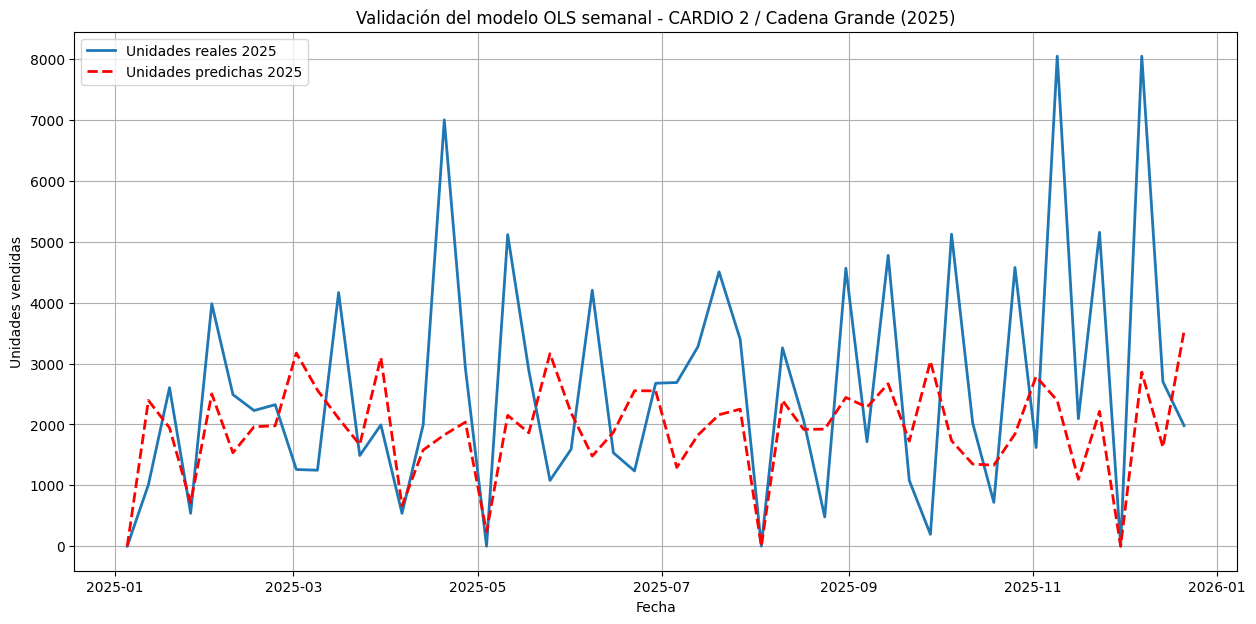

In [342]:

# ENTRENAR MODELO OLS Y VALIDAR EN 2025
modelo_actual = sm.OLS(y_train, X_train).fit()

pred_test_2025 = modelo_actual.predict(X_test).clip(lower=0)

def wape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return 100 * np.abs(y_true - y_pred).sum() / denom

print(modelo_actual.summary())

print("\nMétricas en 2025:")
print("MAE :", mean_absolute_error(y_test, pred_test_2025))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_test_2025)))
print("WAPE:", wape(y_test, pred_test_2025))
print("R2  :", r2_score(y_test, pred_test_2025))

if 'porcentaje_descuento' in modelo_actual.params.index:
    discount_coef = modelo_actual.params['porcentaje_descuento']
    print(f"\nCoeficiente de porcentaje_descuento: {discount_coef:.4f}")

plt.figure(figsize=(15, 7))
plt.plot(test_data['fecha'], y_test.values, label='Unidades reales 2025', linewidth=2)
plt.plot(test_data['fecha'], pred_test_2025, label='Unidades predichas 2025', linestyle='--', color='red', linewidth=2)
plt.title(f'Validación del modelo OLS semanal - {product_name} / {categoria} (2025)')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.grid(True)
plt.show()



In [343]:

# PREDICCIÓN RECURSIVA PARA 2026
future_dates_2026 = pd.date_range('2026-01-04', periods=future_periods, freq='W-SUN')

hist = serie_weekly[['fecha', 'unidades', 'precio_neto', 'porcentaje_descuento']].copy()
hist = hist.sort_values('fecha').reset_index(drop=True)

ultimo_precio = hist['precio_neto'].dropna().iloc[-1]
future_rows = []

for f in future_dates_2026:
    temp = pd.concat([
        hist,
        pd.DataFrame([{
            'fecha': f,
            'unidades': np.nan,
            'precio_neto': ultimo_precio,
            'porcentaje_descuento': scenario_discount
        }])
    ], ignore_index=True)

    temp['year'] = temp['fecha'].dt.year
    temp['month'] = temp['fecha'].dt.month
    temp['quarter'] = temp['fecha'].dt.quarter
    temp['weekofyear'] = temp['fecha'].dt.isocalendar().week.astype(int)

    for lag in [1, 2, 4, 8]:
        temp[f'lag_{lag}'] = temp['unidades'].shift(lag)

    for w in [4, 8]:
        temp[f'rollmean_{w}'] = temp['unidades'].shift(1).rolling(w).mean()

    for lag in [1, 2, 4]:
        temp[f'dcto_lag_{lag}'] = temp['porcentaje_descuento'].shift(lag)

    x_new = sm.add_constant(temp.iloc[[-1]][feature_cols], has_constant='add')
    y_new = modelo_actual.predict(x_new).iloc[0]
    y_new = max(0, y_new)

    nueva_fila = {
        'fecha': f,
        'unidades': y_new,
        'precio_neto': ultimo_precio,
        'porcentaje_descuento': scenario_discount
    }

    hist = pd.concat([hist, pd.DataFrame([nueva_fila])], ignore_index=True)
    future_rows.append(nueva_fila)

predictions_df_2026 = pd.DataFrame(future_rows)

print("Primeras filas de las predicciones para 2026:")
display(predictions_df_2026.head())

print("Últimas filas de las predicciones para 2026:")
display(predictions_df_2026.tail())


Primeras filas de las predicciones para 2026:


,fecha,unidades,precio_neto,porcentaje_descuento
0,2026-01-04,4488.683080,2.866021,0.25
1,2026-01-11,3943.494182,2.866021,0.25
2,2026-01-18,3709.567400,2.866021,0.25
3,2026-01-25,3589.184870,2.866021,0.25
4,2026-02-01,4083.767807,2.866021,0.25


Últimas filas de las predicciones para 2026:


,fecha,unidades,precio_neto,porcentaje_descuento
47,2026-11-29,4317.620168,2.866021,0.25
48,2026-12-06,4572.816121,2.866021,0.25
49,2026-12-13,4538.806114,2.866021,0.25
50,2026-12-20,4549.173339,2.866021,0.25
51,2026-12-27,4519.295716,2.866021,0.25


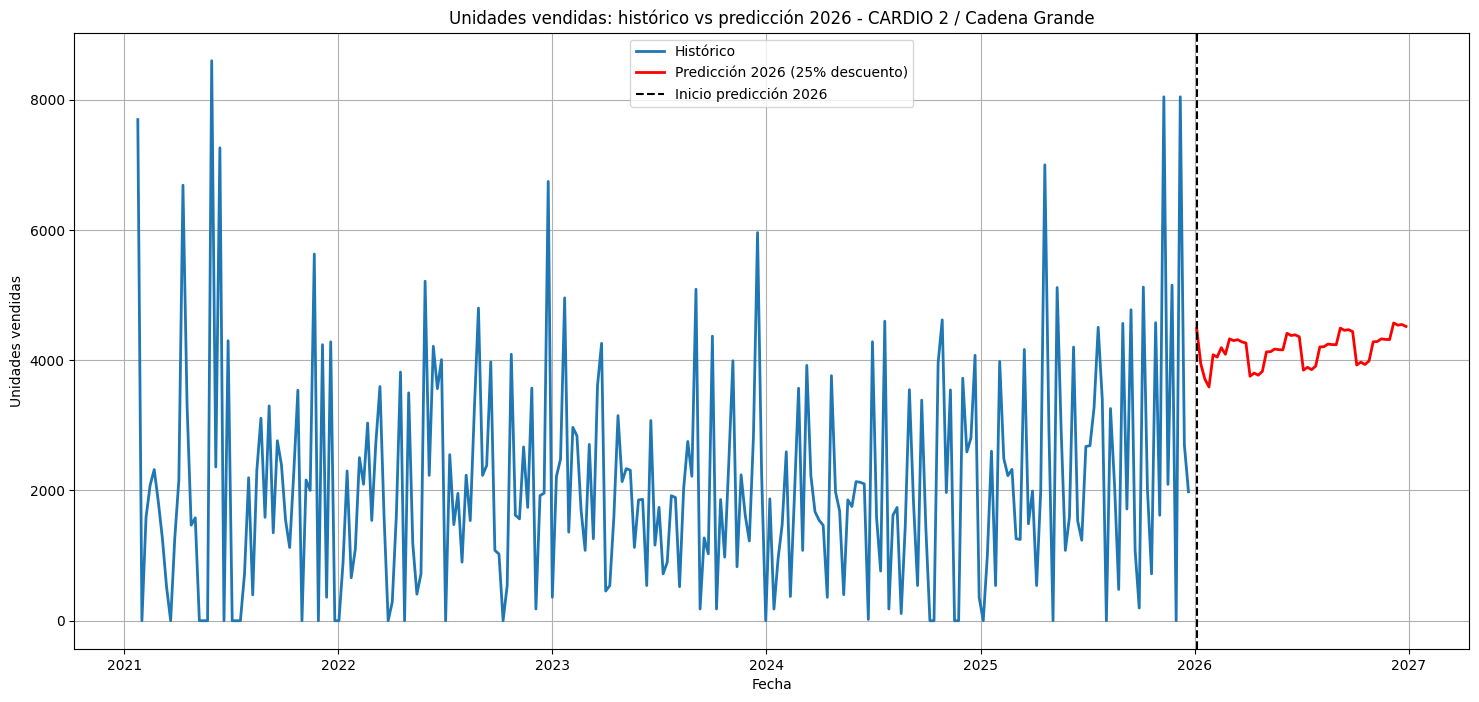

In [344]:

# GRÁFICO FINAL: HISTÓRICO DEL MISMO PRODUCTO/CATEGORÍA + PREDICCIÓN 2026
historical_data = serie_weekly[serie_weekly['fecha'] < predictions_df_2026['fecha'].min()].copy()

plt.figure(figsize=(18, 8))
plt.plot(historical_data['fecha'], historical_data['unidades'], label='Histórico', linewidth=2)
plt.plot(
    predictions_df_2026['fecha'],
    predictions_df_2026['unidades'],
    label=f'Predicción 2026 ({int(scenario_discount*100)}% descuento)',
    linewidth=2,
    color='red'
)

plt.axvline(
    x=predictions_df_2026['fecha'].min(),
    color='black',
    linestyle='--',
    label='Inicio predicción 2026'
)

plt.title(f'Unidades vendidas: histórico vs predicción 2026 - {product_name} / {categoria}')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.grid(True)
plt.show()


In [345]:
total_predicted_units_2026 = predictions_df_2026['unidades'].sum()
print(f"La suma total de unidades predichas para 2026 es: {total_predicted_units_2026:.2f}")

La suma total de unidades predichas para 2026 es: 217149.64


In [346]:
valor_total_ventas_2026 = total_predicted_units_2026 * ultimo_precio
print(f"El valor total de ventas predichas para 2026 (unidades * precio promedio) es: {valor_total_ventas_2026:.2f}")

El valor total de ventas predichas para 2026 (unidades * precio promedio) es: 622355.32


In [347]:
total_costo_2026 = total_predicted_units_2026 * median_costo_unitario
print(f"El costo total estimado para las unidades predichas en 2026 es: {total_costo_2026:.2f}")

beneficio_bruto_2026 = (valor_total_ventas_2026 - total_costo_2026)/valor_total_ventas_2026
print(f"El beneficio bruto estimado para 2026 es: {beneficio_bruto_2026:.2f}")

El costo total estimado para las unidades predichas en 2026 es: 108366.86
El beneficio bruto estimado para 2026 es: 0.83
